In [3]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time_normalization_helpers

In [5]:
dbd_norm_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities.csv")
dbd_norm_activities = dbd_norm_activities[["ADseq",  "AD_BC", "RPTR_BC", "time", "rep", "shifted_activity"]]
# dbd_norm_activities = dbd_norm_activities.groupby(["ADseq", "rep", "time"])[["shifted_activity"]].agg(["mean", "std"]).reset_index()
# dbd_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dbd_norm_activities.columns]
# dbd_norm_activities = dbd_norm_activities[dbd_norm_activities["rep_"] == 2]
# dbd_norm_activities = dbd_norm_activities.dropna()
df = dbd_norm_activities
df["bio_rep"] = df["AD_BC"] + "_" + df["RPTR_BC"]
df

,ADseq,AD_BC,RPTR_BC,time,rep,shifted_activity,bio_rep
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,TGAGAGAAAATCTA,0,2,-0.150595,ATAACCAATGG_TGAGAGAAAATCTA
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,CCCTCACCCGATTA,0,2,-0.329160,TATCTTCGCTT_CCCTCACCCGATTA
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGA,TTTGATATCCAAAC,0,2,-0.396107,AATCGTACCGA_TTTGATATCCAAAC
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,TATTGTTCTCTGCT,0,2,-0.748290,TTGCATAGCTG_TATTGTTCTCTGCT
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,CATCGAACCTGAAC,0,2,-0.073888,TTTATAATACC_CATCGAACCTGAAC
...,...,...,...,...,...,...,...
1361924,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,CAATTGACACTACG,60,4,-0.375924,CCAAACTTGGA_CAATTGACACTACG
1361925,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,CGCACGAATACCCG,60,4,-0.207950,CCCACTCTCAG_CGCACGAATACCCG
1361926,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAAT,CAACAGCCCTTACG,60,4,0.320323,GGGTCGTAAAT_CAACAGCCCTTACG
1361927,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,CTCTGCTACTTGTG,60,4,0.324968,GATCCCATGCA_CTCTGCTACTTGTG


# Do technical replicates look similar to one another?

In [6]:
dbd_norm_activities_pivot = pd.pivot(dbd_norm_activities, index = ["ADseq", "AD_BC", "RPTR_BC", "time"], columns = 'rep', values = "shifted_activity").reset_index()
dbd_norm_activities_pivot

rep,ADseq,AD_BC,RPTR_BC,time,2,3,4
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,ACGGTTATCTT,CCCCCAAGTACAAA,15,1.460117,NaN,NaN
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,ACGGTTATCTT,CCCCCAAGTACAAA,30,NaN,0.755067,NaN
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,0,NaN,NaN,0.214090
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,2,0.289811,NaN,NaN
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,5,0.244774,NaN,0.350857
...,...,...,...,...,...,...,...
538773,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,20,-0.051318,-0.402958,-0.129411
538774,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,30,-0.396917,-0.314971,-0.372179
538775,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,40,-0.182364,-0.236812,-0.391847
538776,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,50,-0.309561,0.009354,-0.380567


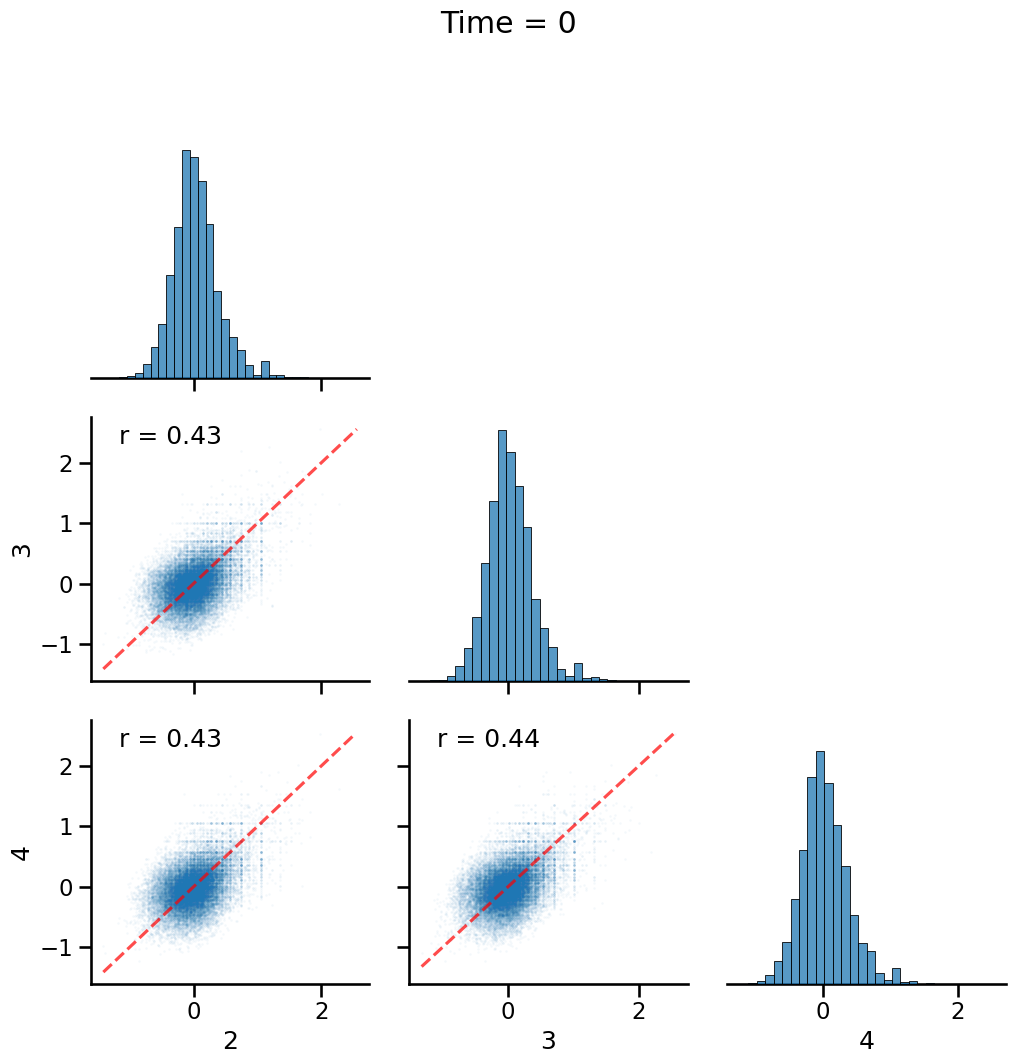

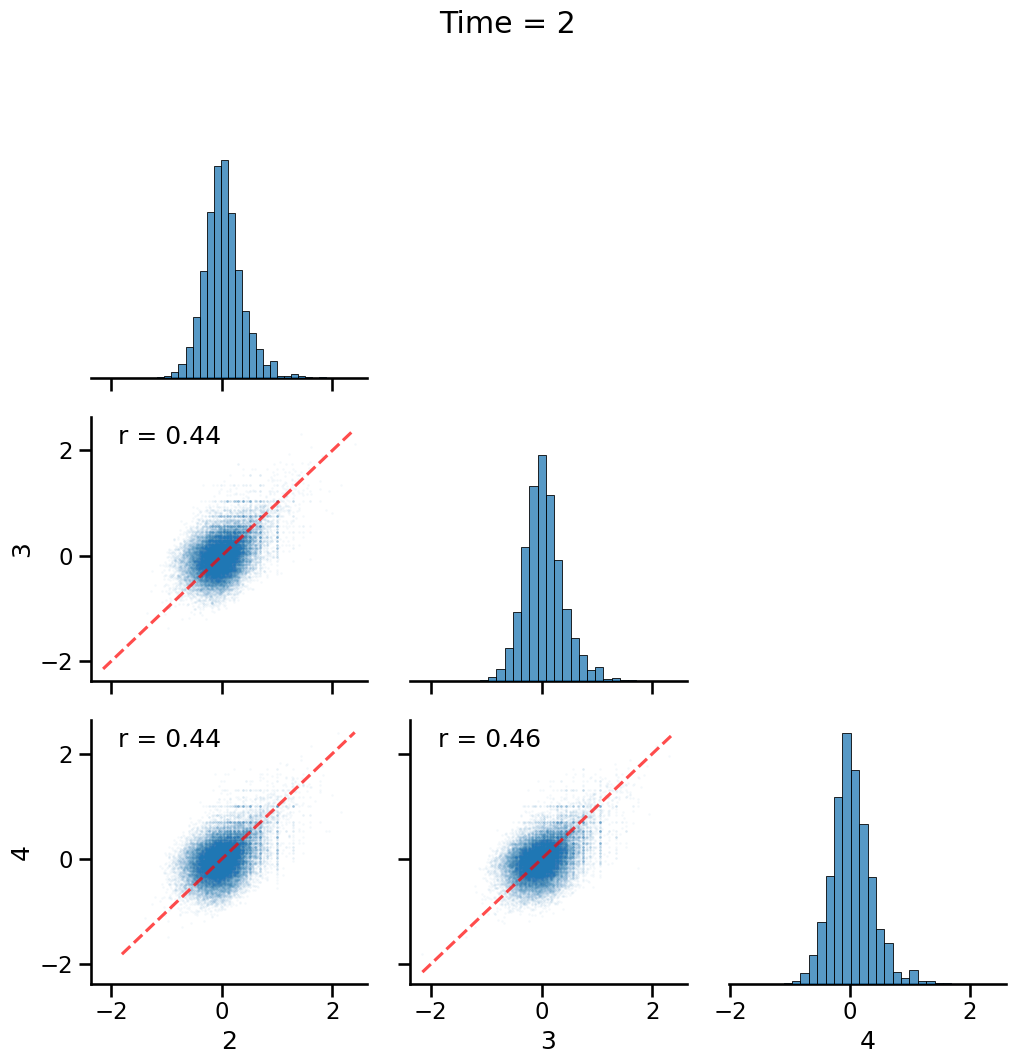

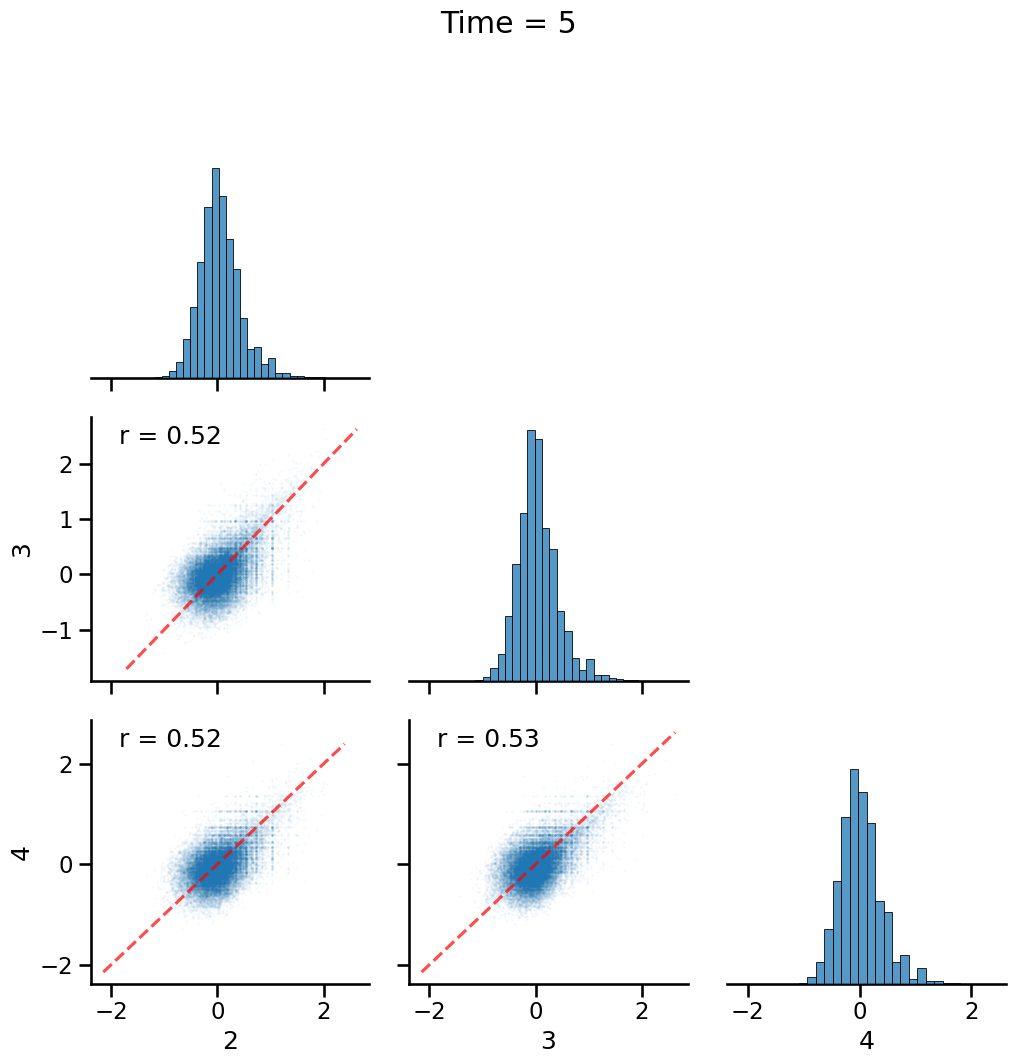

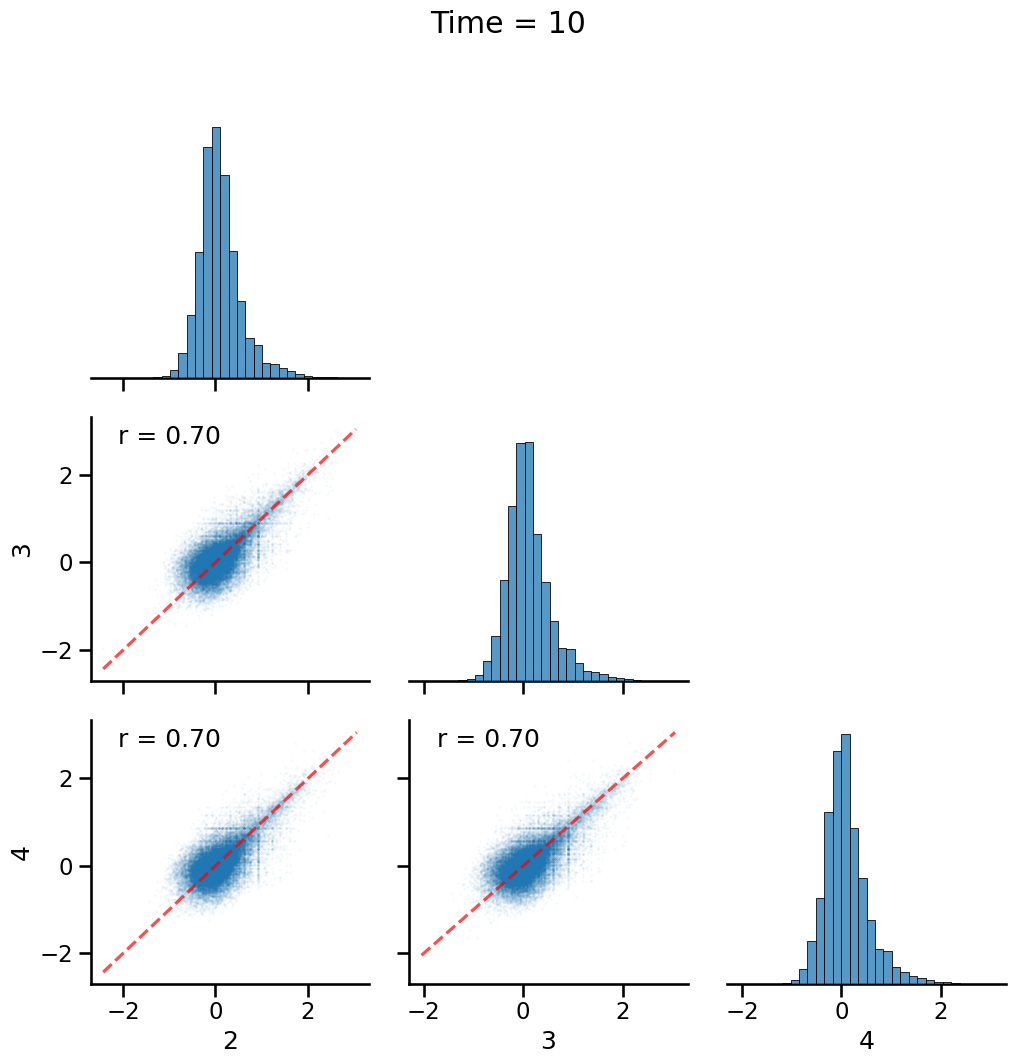

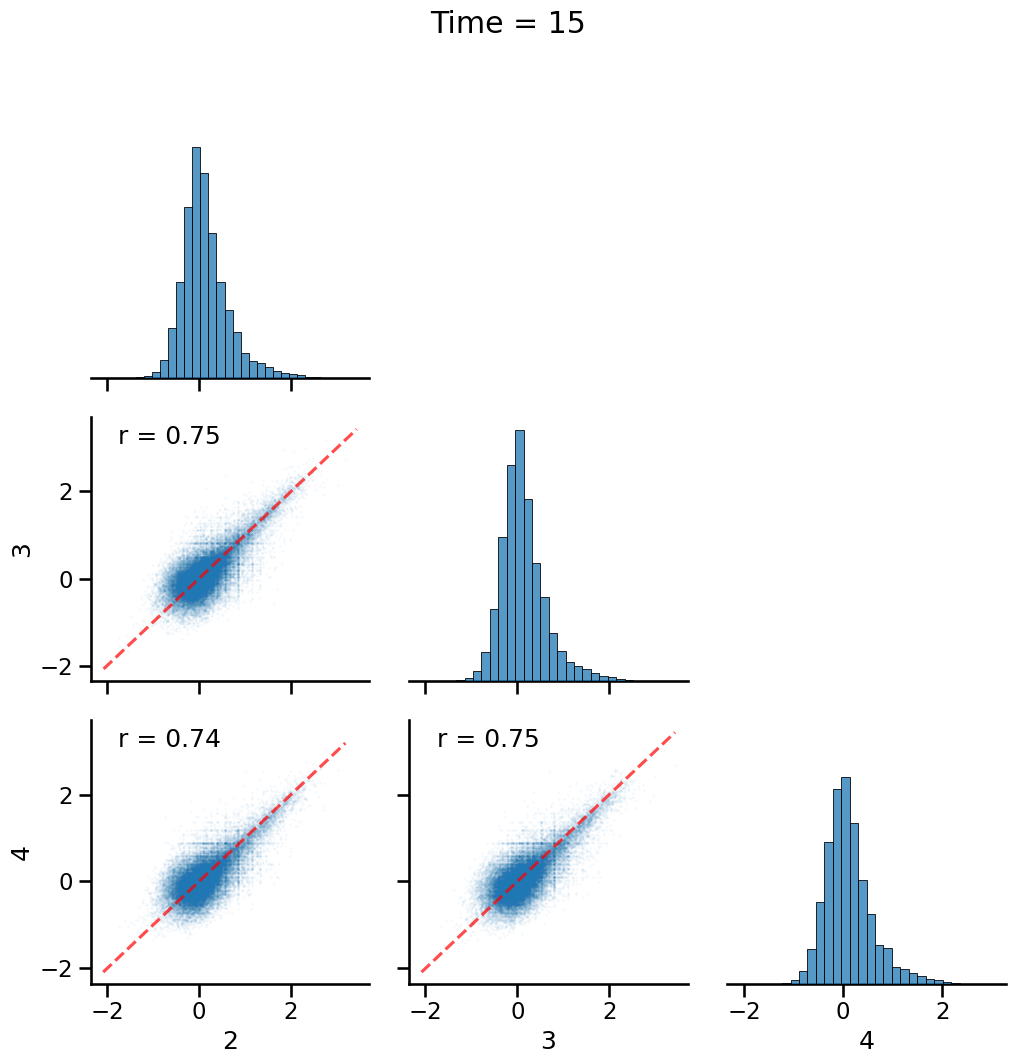

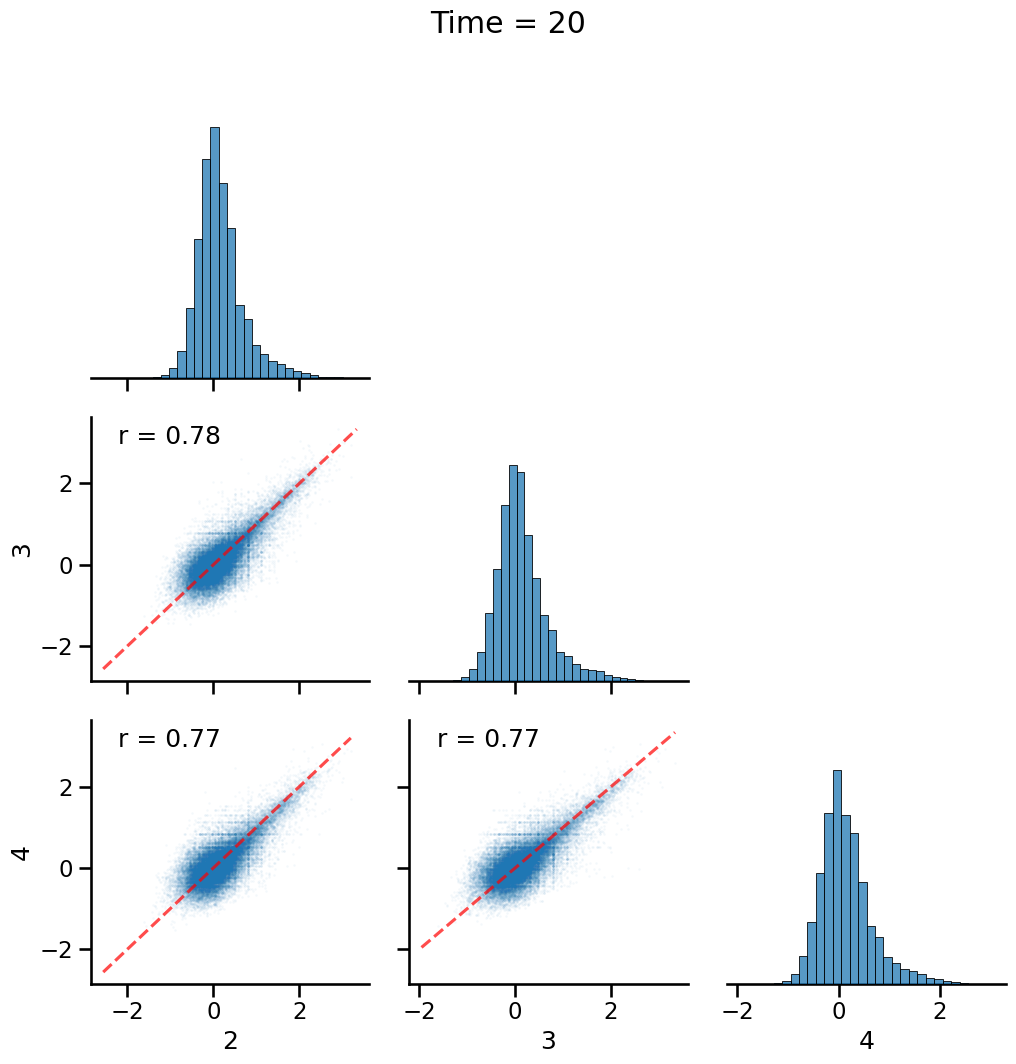

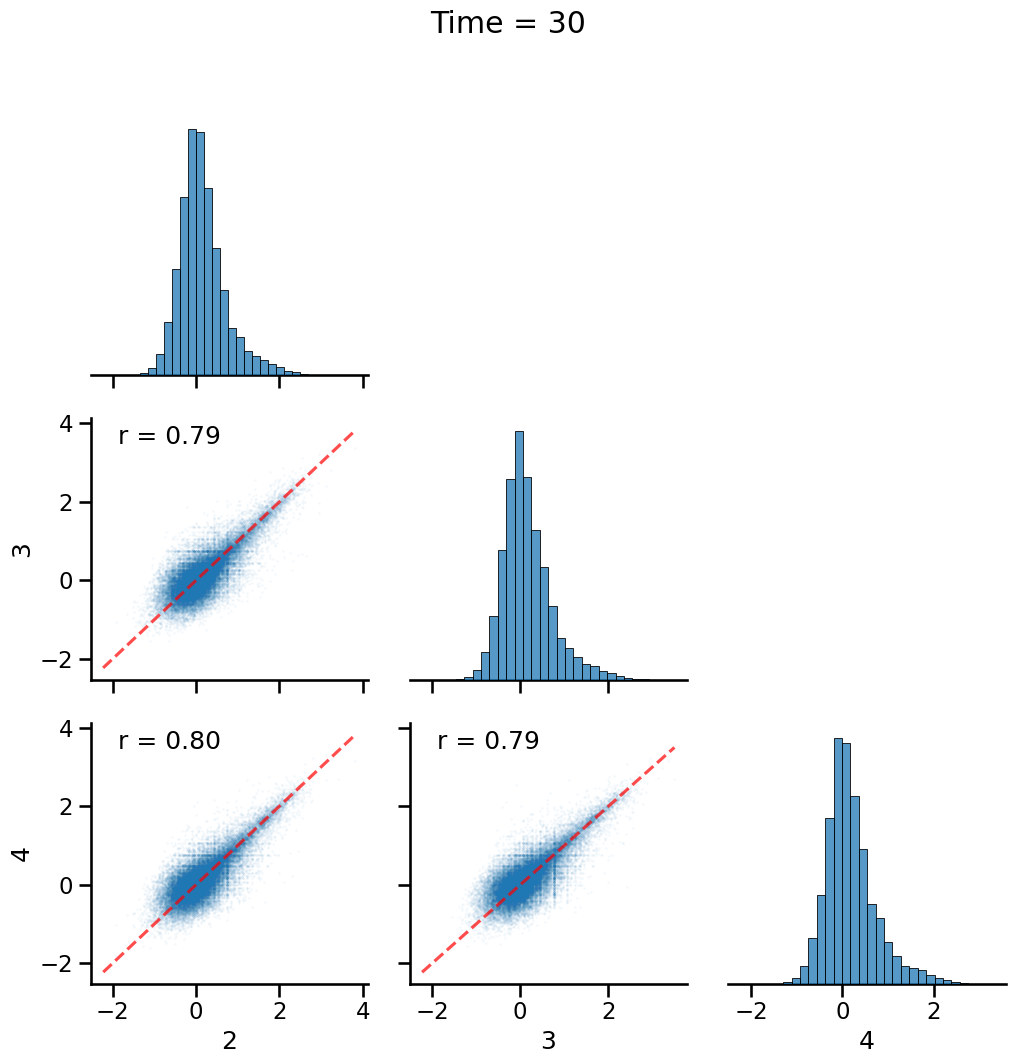

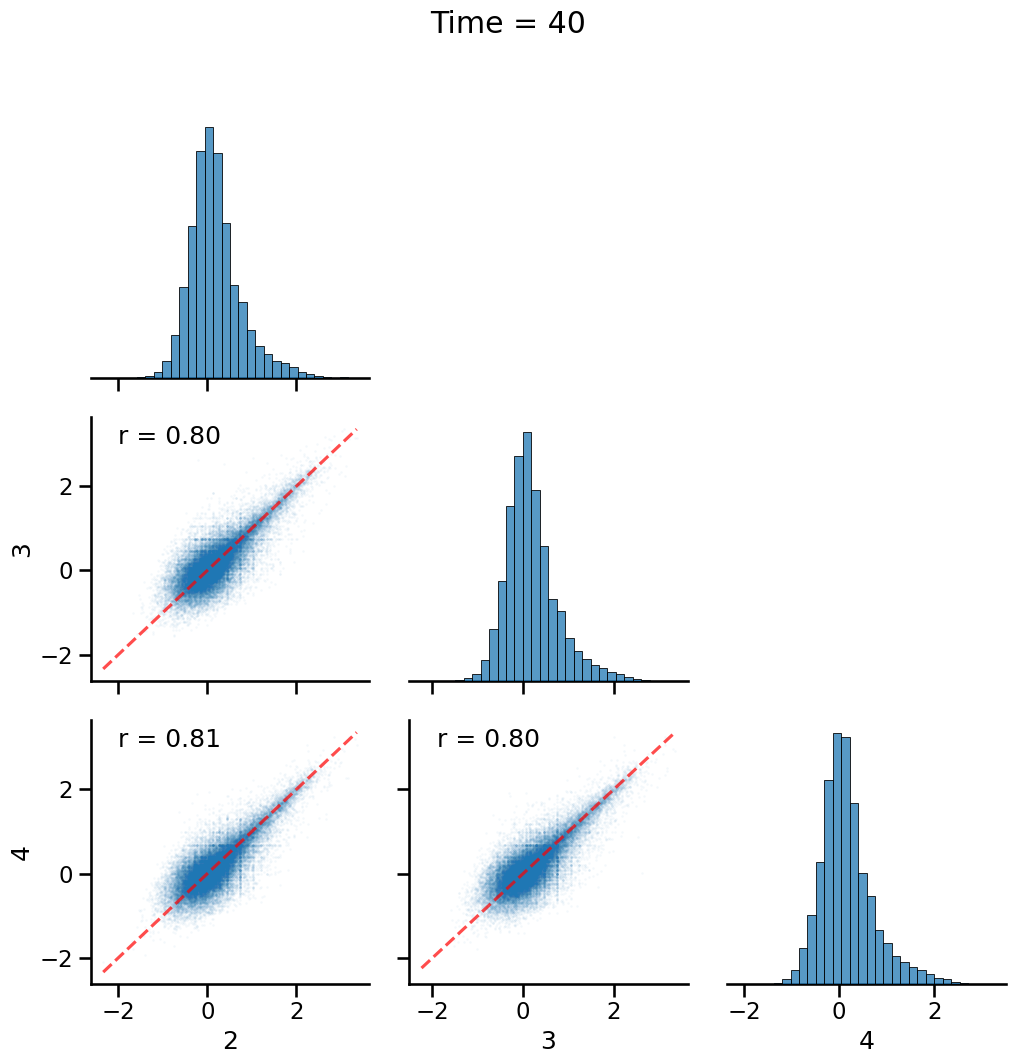

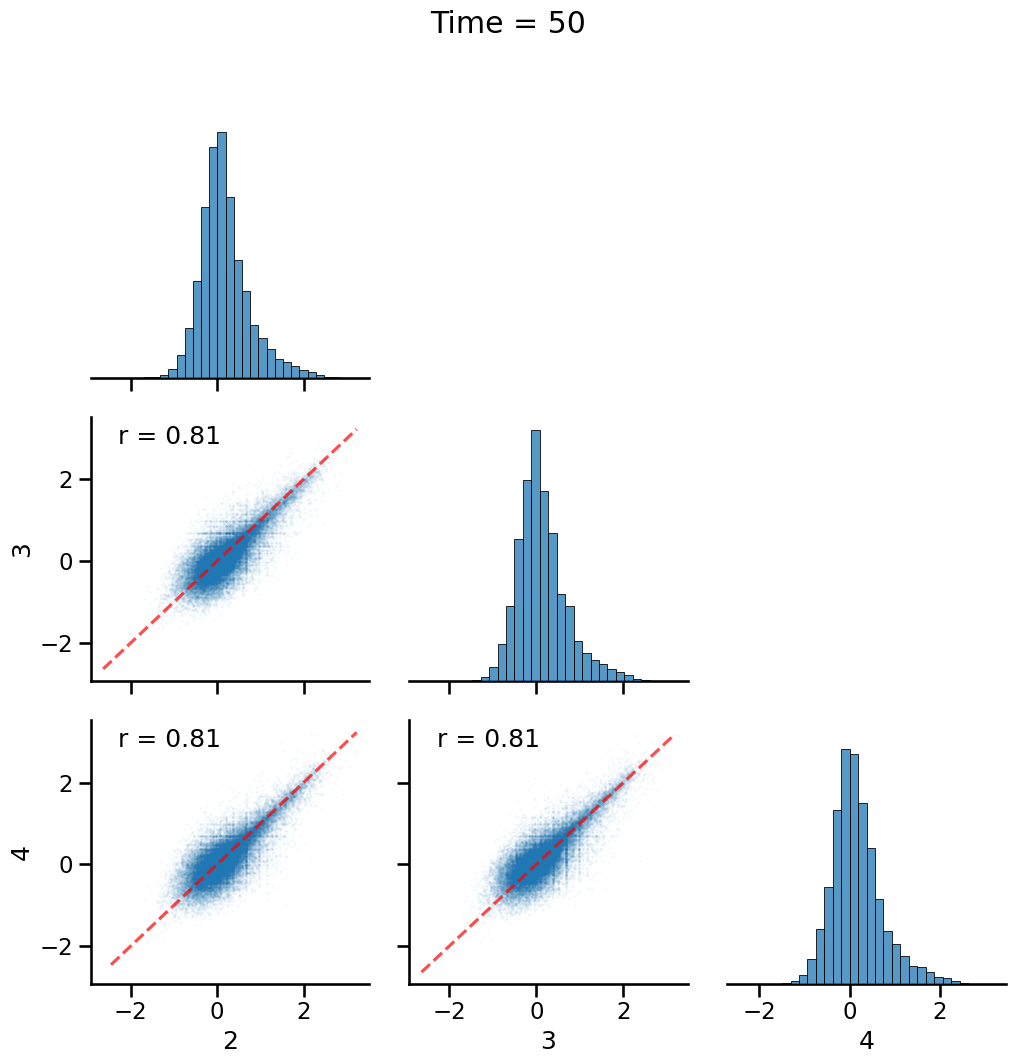

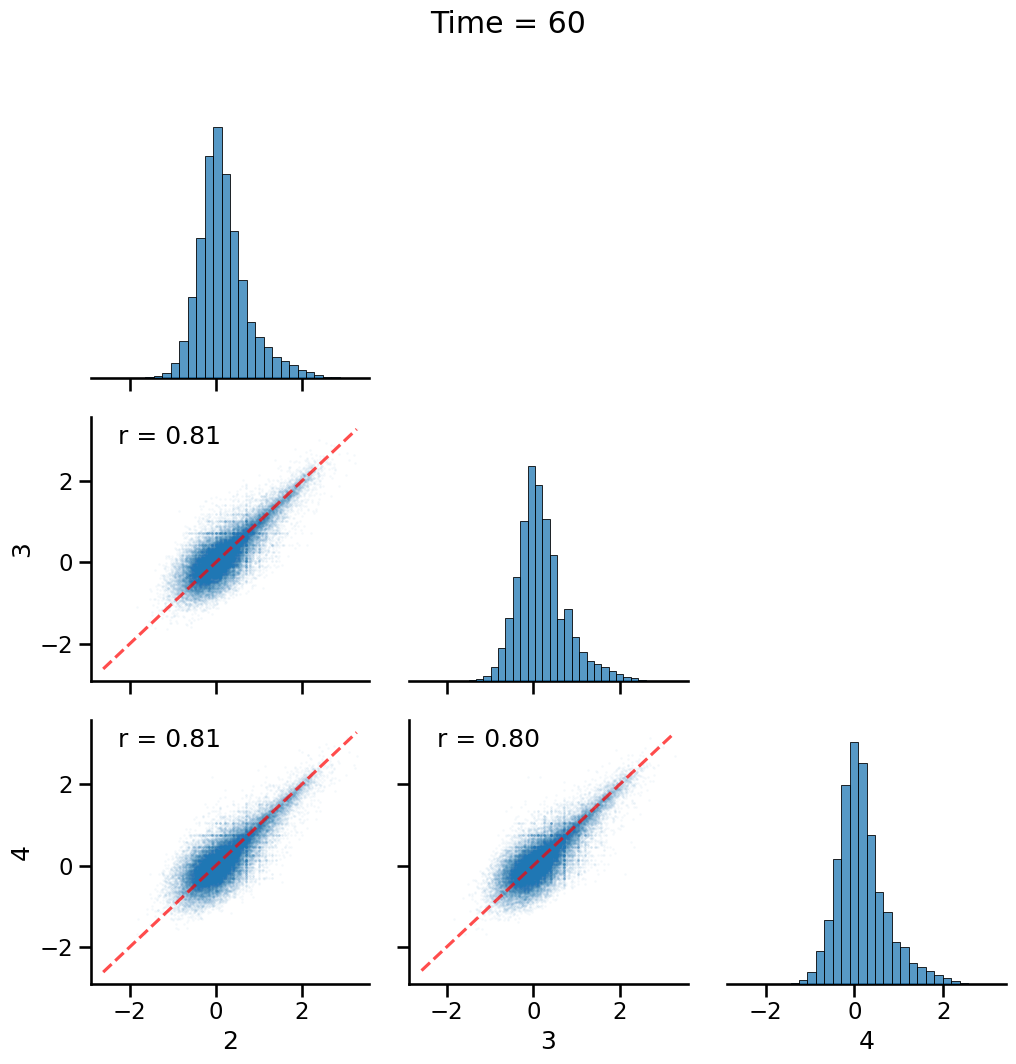

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_context("talk")

cols = [2, 3, 4]

def identity_line(x, y, **kws):
    ax = plt.gca()
    lims = [
        np.nanmin([x, y]),
        np.nanmax([x, y])
    ]
    ax.plot(lims, lims, '--', color='red', alpha=0.7)
    
for t in sorted(dbd_norm_activities_pivot["time"].unique()):
    df_t = dbd_norm_activities_pivot[
        dbd_norm_activities_pivot["time"] == t
    ][cols]

    g = sns.pairplot(
        df_t,
        kind="scatter",
        corner=True,   
        height=3.5,
        plot_kws={
            "s": 3,
            "alpha": 0.05,
            "linewidth": 0
        },
        diag_kws={"bins": 30}
    )

    # --- robust correlation annotation ---
    def corrfunc(x, y, **kws):
        # drop NaNs pairwise
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]

        ax = plt.gca()

        if len(x_clean) < 2 or np.std(x_clean) == 0 or np.std(y_clean) == 0:
            ax.annotate("r = NA", xy=(0.1, 0.9), xycoords=ax.transAxes)
        else:
            r = np.corrcoef(x_clean, y_clean)[0, 1]
            ax.annotate(f"r = {r:.2f}", xy=(0.1, 0.9), xycoords=ax.transAxes)

    g.map_lower(corrfunc)
    g.map_lower(identity_line)

    g.fig.suptitle(f"Time = {t}", y=1.02)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2247095/2612287795.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1], pad=0.5)


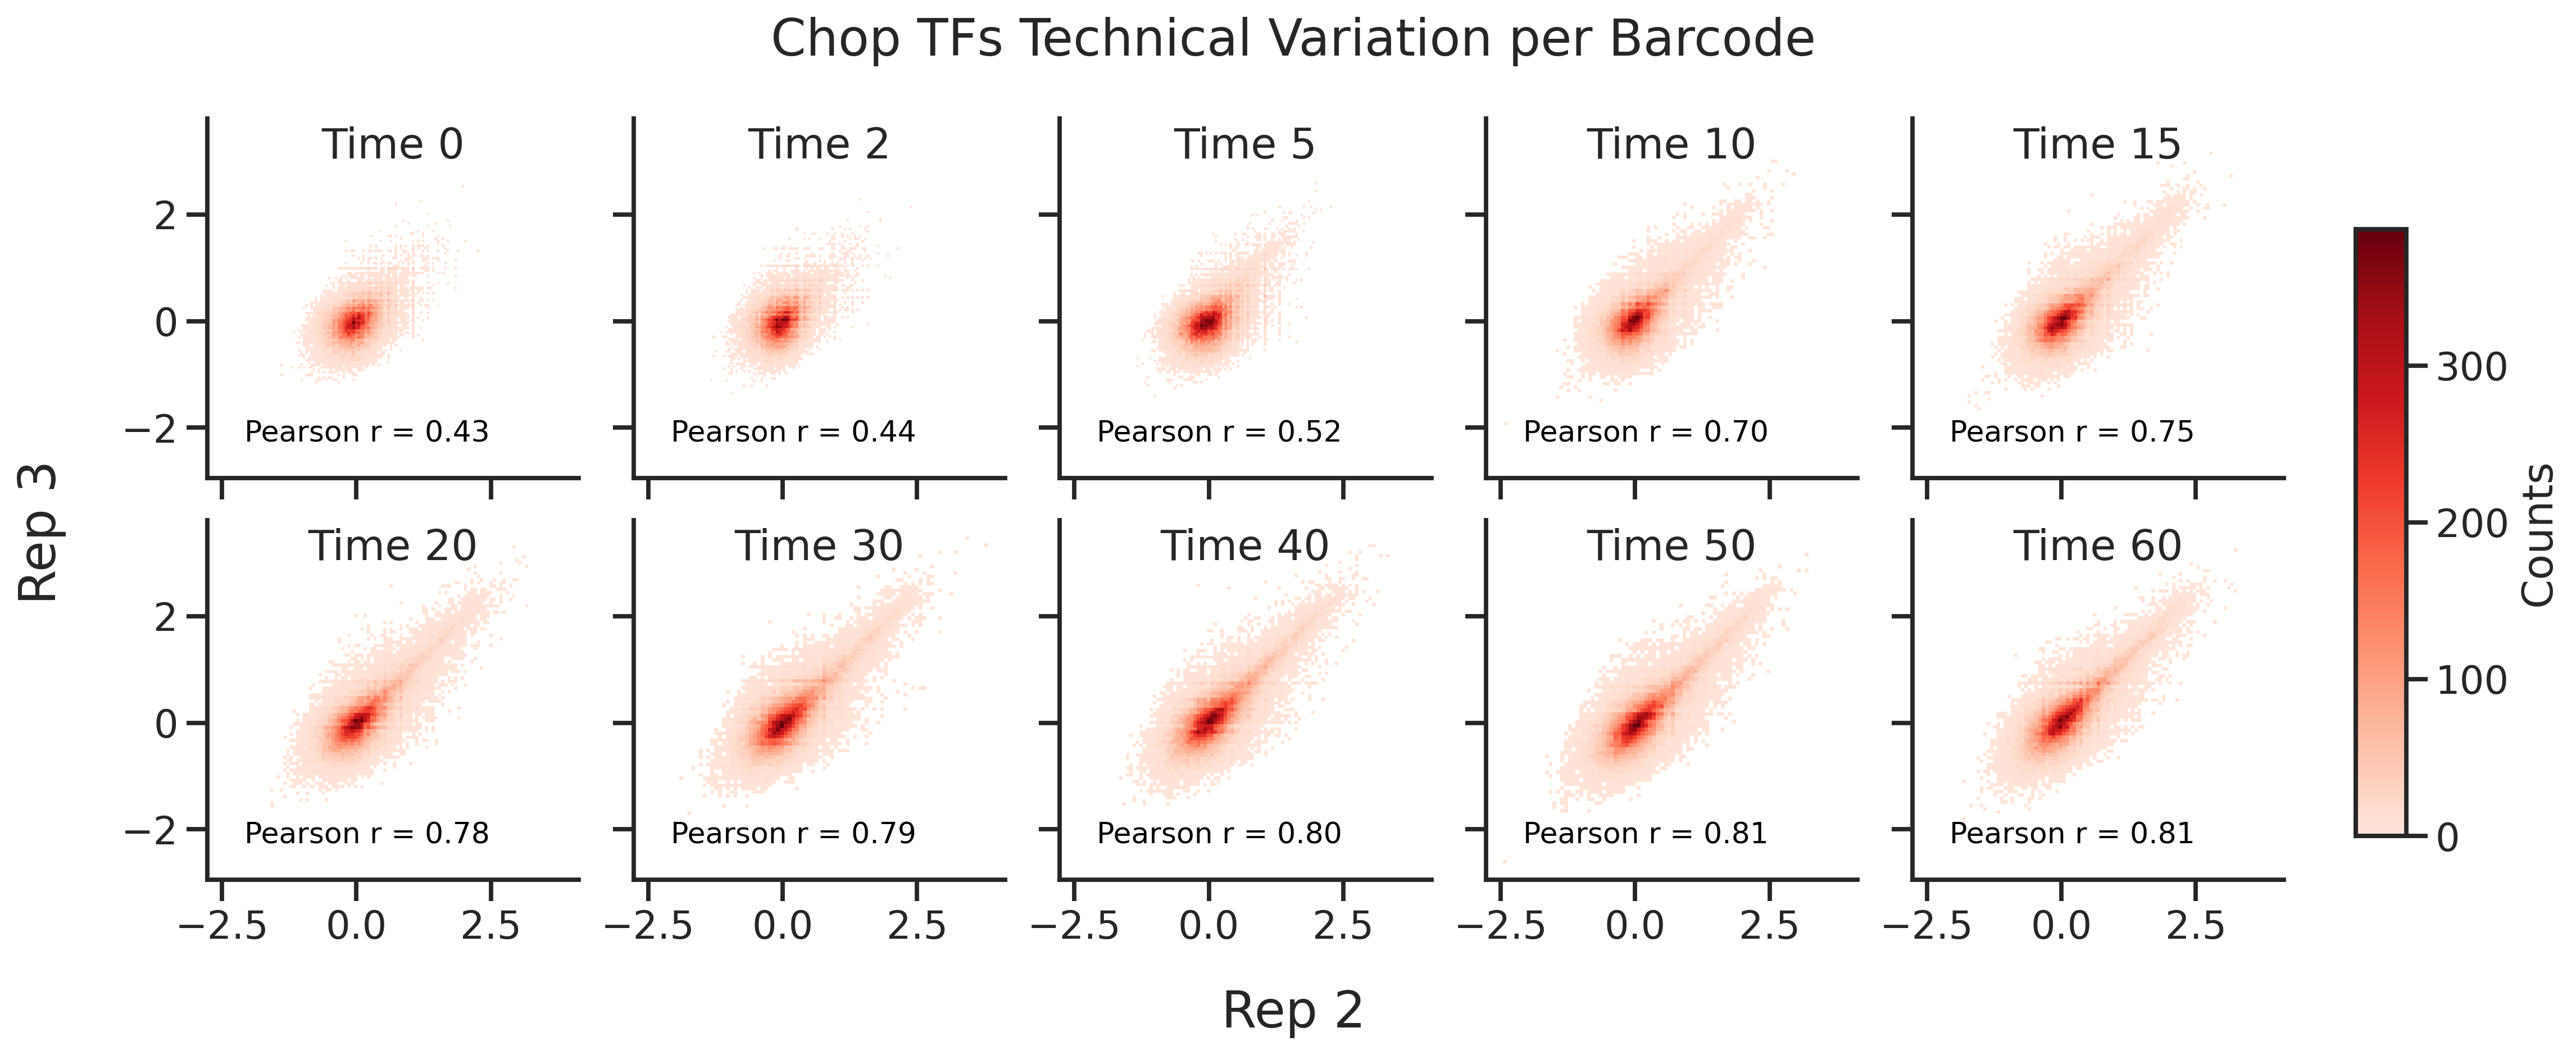

/tmp/ipykernel_2247095/2612287795.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1], pad=0.5)


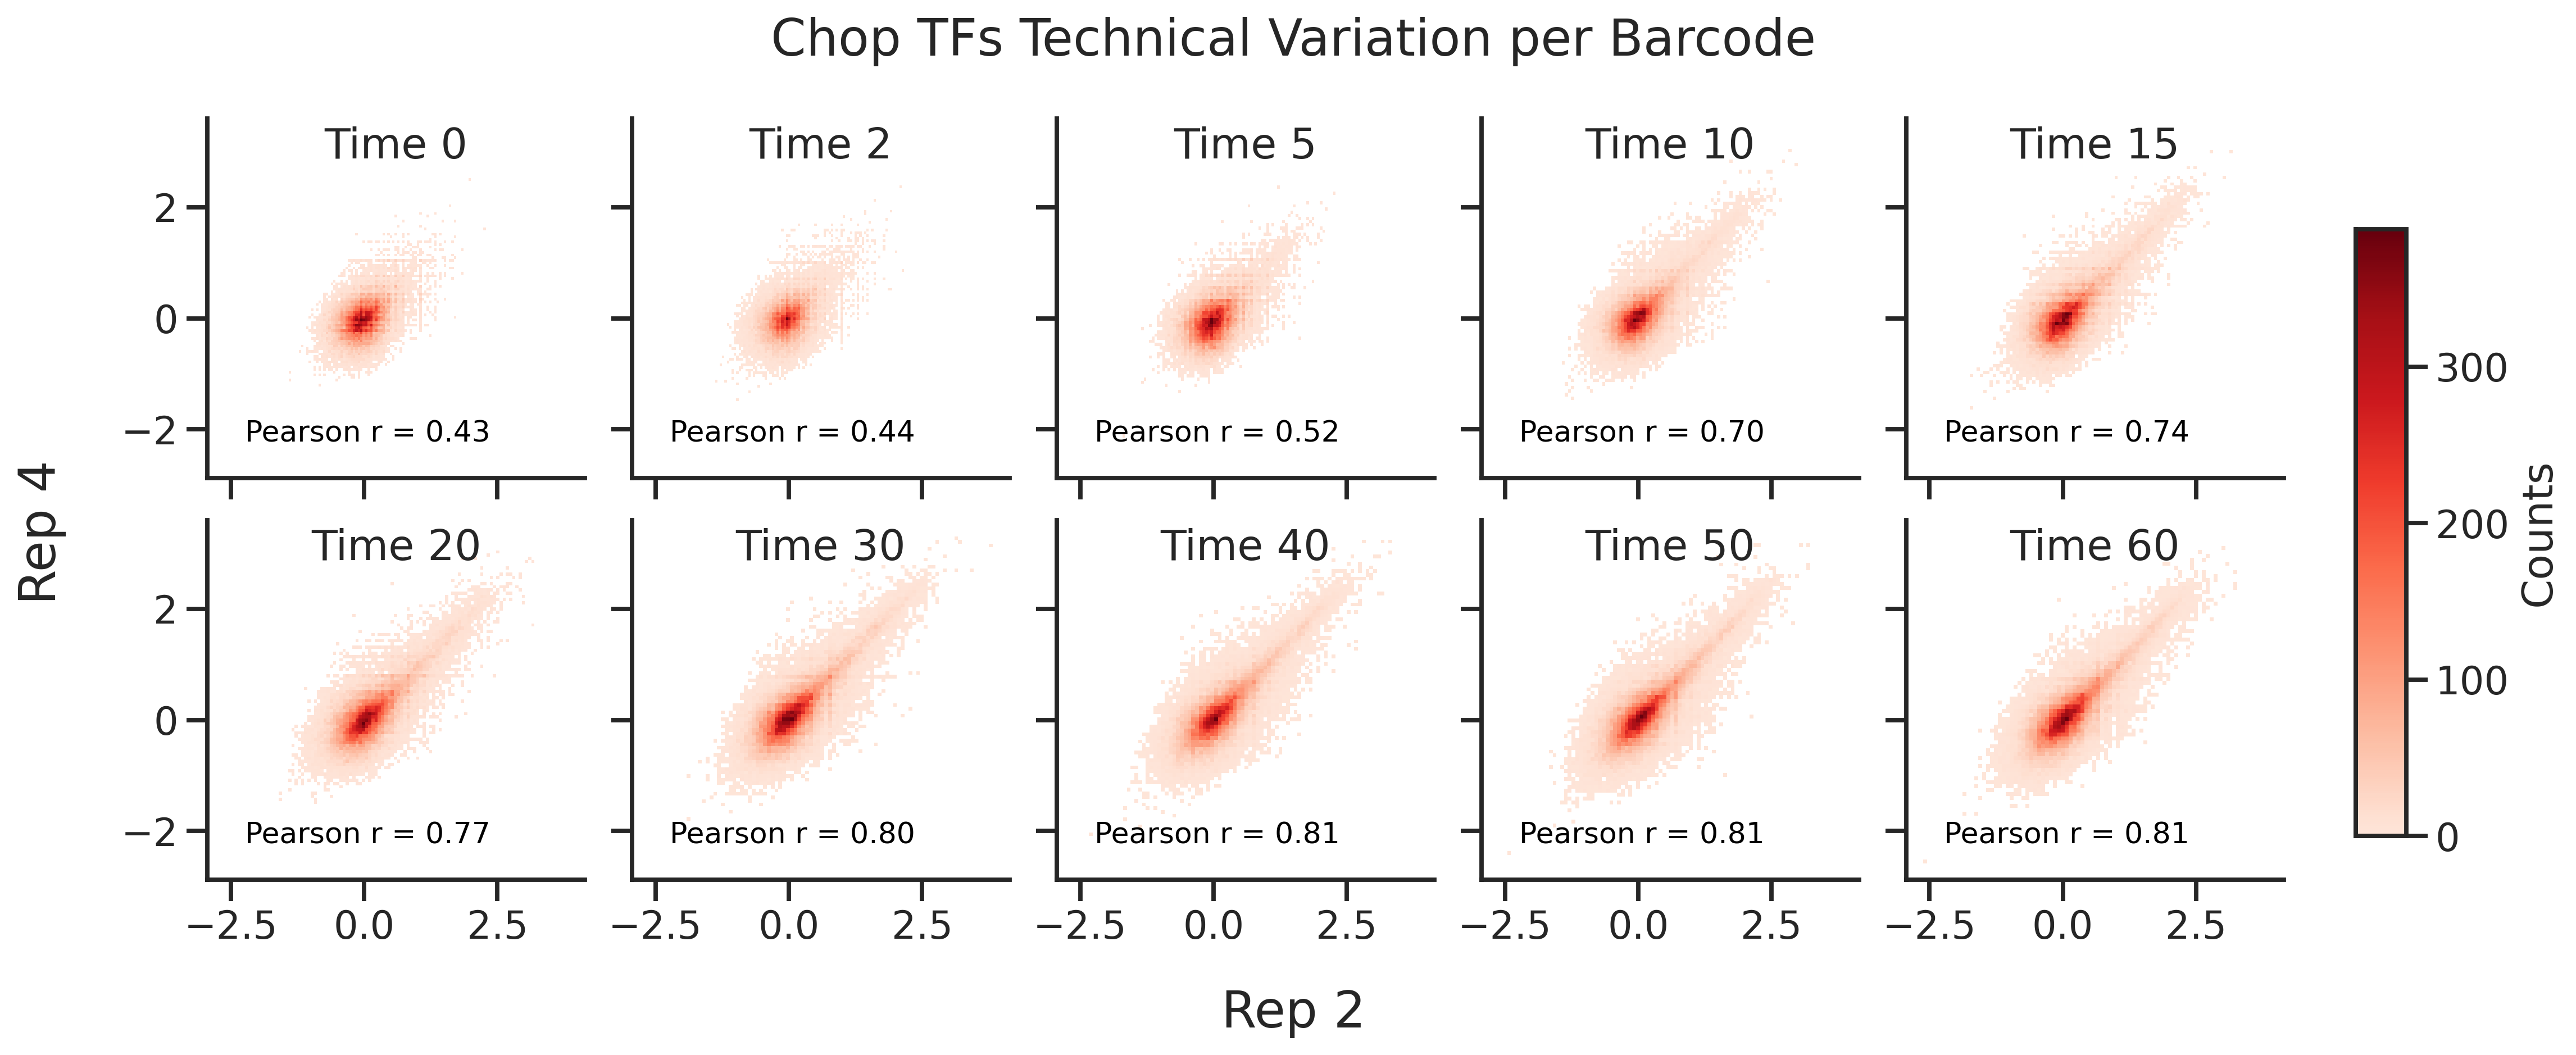

/tmp/ipykernel_2247095/2612287795.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1], pad=0.5)


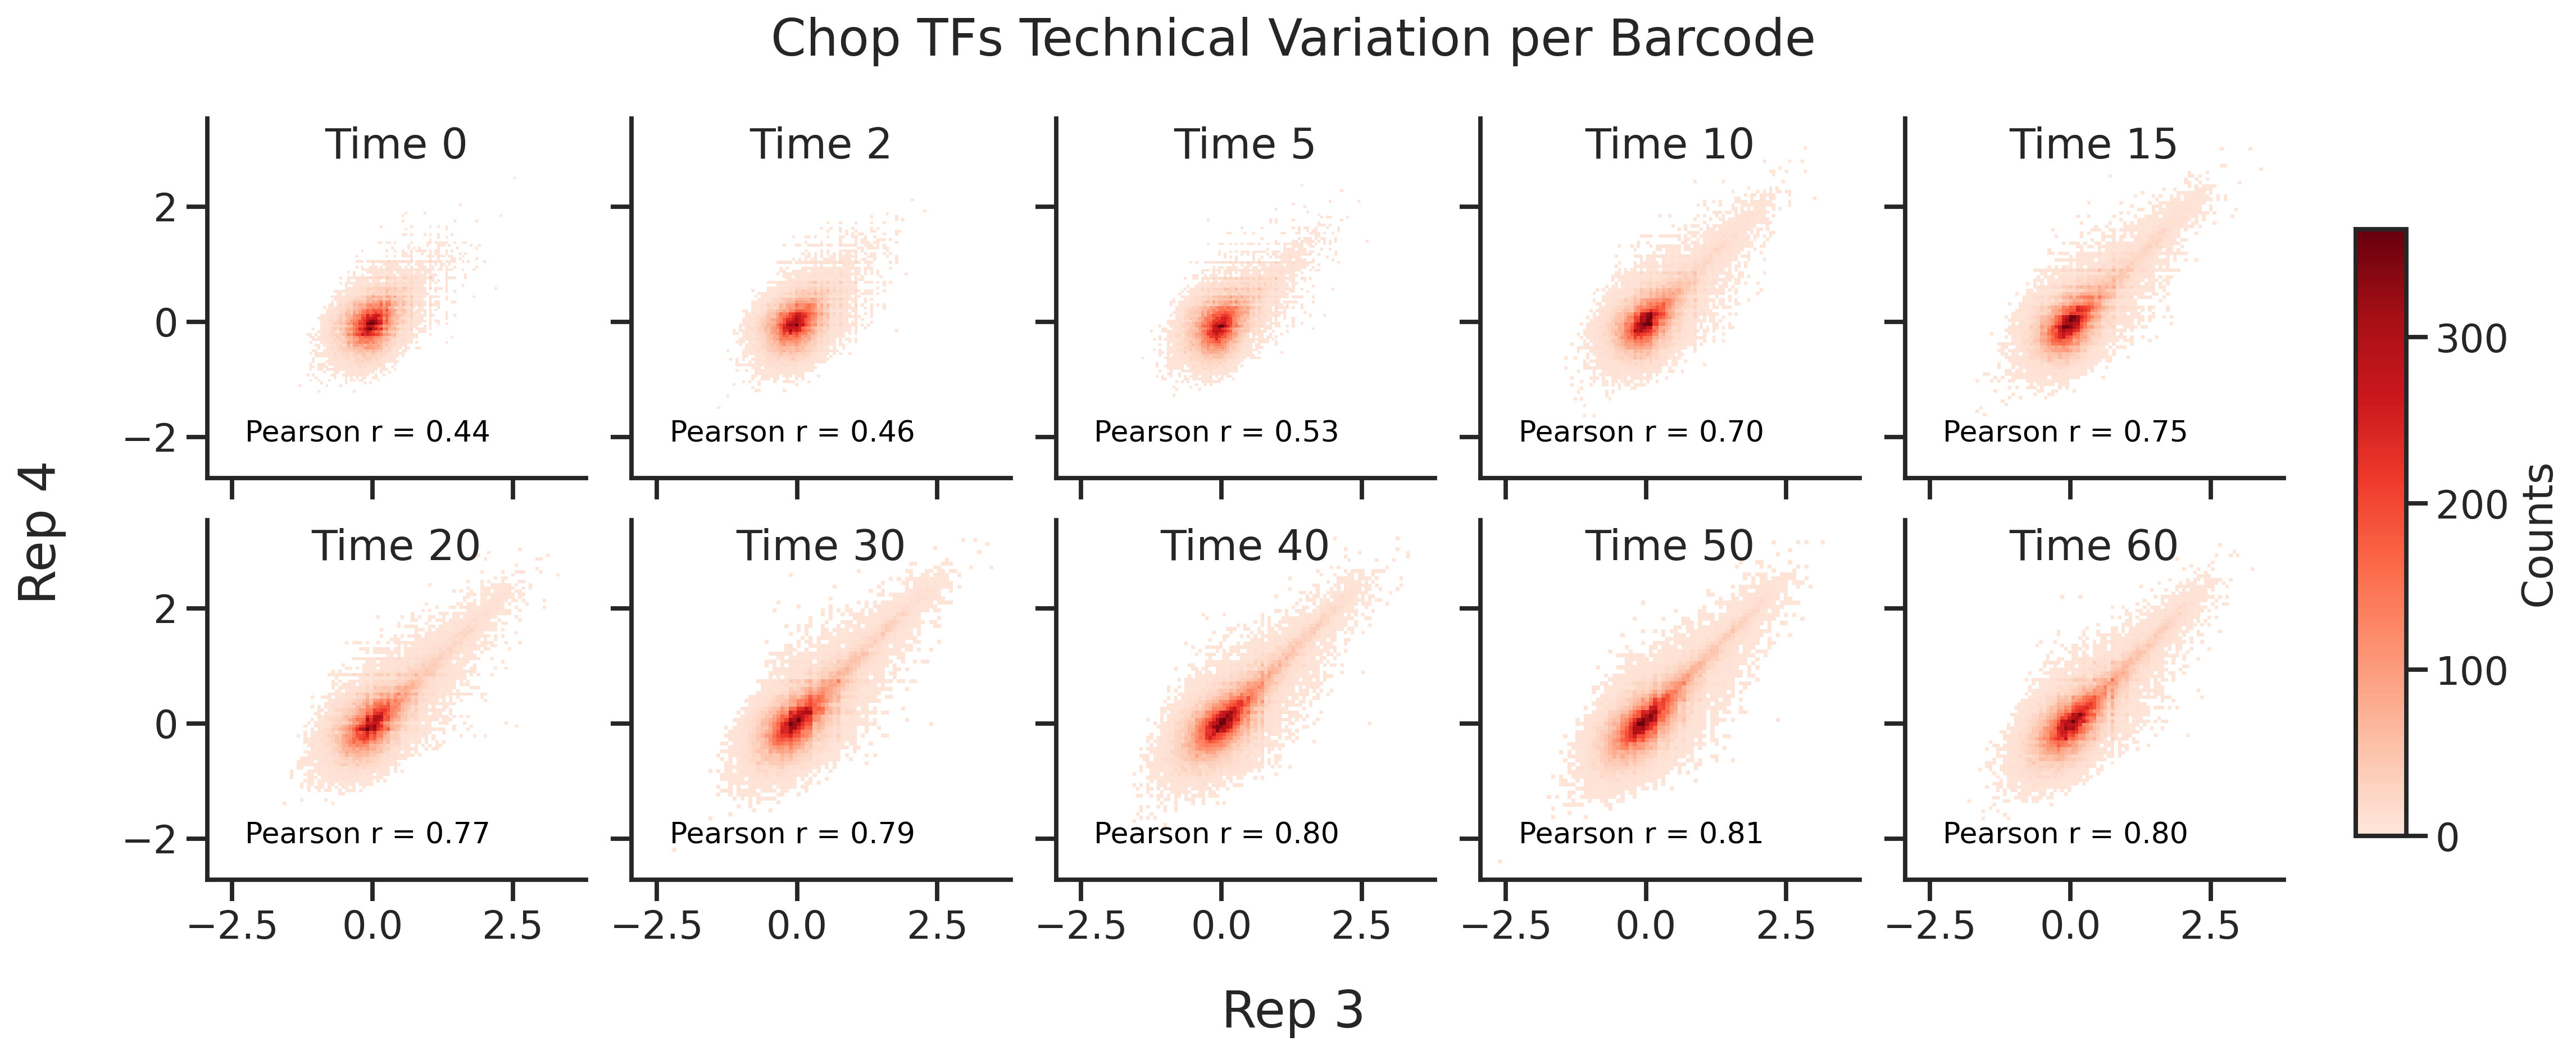

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

sns.set_context("talk")
sns.set_style('ticks')

cols = [2, 3, 4]
times = sorted(dbd_norm_activities_pivot["time"].unique())
rep_pairs = [(2, 3), (2, 4), (3, 4)]

# --- Truncate colormap ---
def truncate_colormap(cmap, minval=0.1, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mpl.colors.LinearSegmentedColormap.from_list("trunc", new_colors)

cmap = truncate_colormap(mpl.cm.Reds, 0.1, 1.0)

for rep1, rep2 in rep_pairs:
    # Prepare figure layout: 2 rows x 5 columns
    n_cols = 5
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows),
                             sharex=True, sharey=True, dpi=300)
    axes = axes.flatten()

    # Compute global max for consistent color scaling
    global_max = 0
    for t in times:
        subset = dbd_norm_activities_pivot[dbd_norm_activities_pivot["time"] == t][[rep1, rep2]].dropna()
        counts, _, _ = np.histogram2d(subset[rep1], subset[rep2], bins=80)
        global_max = max(global_max, counts.max())

    # Global axis limits
    xmin, xmax = dbd_norm_activities_pivot[rep1].min(), dbd_norm_activities_pivot[rep1].max()
    ymin, ymax = dbd_norm_activities_pivot[rep2].min(), dbd_norm_activities_pivot[rep2].max()
    xpad, ypad = 1, 1
    xmin, xmax = xmin - xpad, xmax + xpad
    ymin, ymax = ymin - ypad, ymax + ypad

    # --- Plot each time point ---
    for i, t in enumerate(times):
        ax = axes[i]
        subset = dbd_norm_activities_pivot[dbd_norm_activities_pivot["time"] == t][[rep1, rep2]].dropna()
        
        # 2D histogram / heatmap
        sns.histplot(
            x=subset[rep1],
            y=subset[rep2],
            bins=80,
            cmap=cmap,
            cbar=False,
            ax=ax
        )
        # ax.set_xlim(xmin, xmax)
        # ax.set_ylim(ymin, ymax)
        ax.set_title(f"Time {t}", y=0.85)
        ax.set_xlabel("")
        ax.set_ylabel("")

        # --- Identity line ---
        # lims = [min(xmin, ymin), max(xmax, ymax)]
        # ax.plot(lims, lims, '--', color='red', alpha=0.7)

        # --- Pearson correlation ---
        mask = ~np.isnan(subset[rep1]) & ~np.isnan(subset[rep2])
        x_clean = subset[rep1][mask]
        y_clean = subset[rep2][mask]
        if len(x_clean) >= 2 and np.std(x_clean) > 0 and np.std(y_clean) > 0:
            r = np.corrcoef(x_clean, y_clean)[0, 1]
            ax.text(0.1,0.1, f"Pearson r = {r:.2f}", transform=ax.transAxes, color='black', fontsize='x-small')
        else:
            ax.text(0.05, 0.8, "r = NA", transform=ax.transAxes, color='red', fontsize=10)

    # Turn off unused axes (if less than 10 time points)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # Shared axis labels
    fig.supxlabel(f"Rep {rep1}", y=0)
    fig.supylabel(f"Rep {rep2}", x=-0.005)

    # Shared colorbar
    sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=global_max), cmap=cmap)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
    fig.colorbar(sm, cax=cbar_ax, label="Counts")

    fig.suptitle(f"Chop TFs Technical Variation per Barcode", y=1.01)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 0.9, 1], pad=0.5)
    plt.show()

# Which is bigger, technical or biological error?

In [9]:
tech_rep_err = dbd_norm_activities.groupby(["ADseq", "AD_BC", "RPTR_BC", "time"])["shifted_activity"].agg(['mean', 'std', 'count']).reset_index()
tech_rep_err["SE_tech"] = tech_rep_err["std"] / np.sqrt(tech_rep_err["count"])
tech_rep_err["SE_tech_sq"] = tech_rep_err["SE_tech"] ** 2
tech_rep_err

,ADseq,AD_BC,RPTR_BC,time,mean,std,count,SE_tech,SE_tech_sq
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,ACGGTTATCTT,CCCCCAAGTACAAA,15,1.460117,NaN,1,NaN,NaN
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,ACGGTTATCTT,CCCCCAAGTACAAA,30,0.755067,NaN,1,NaN,NaN
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,0,0.214090,NaN,1,NaN,NaN
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,2,0.289811,NaN,1,NaN,NaN
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,5,0.297816,0.075012,2,0.053042,0.002813
...,...,...,...,...,...,...,...,...,...
538773,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,20,-0.194562,0.184651,3,0.106608,0.011365
538774,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,30,-0.361356,0.042031,3,0.024267,0.000589
538775,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,40,-0.270341,0.108691,3,0.062753,0.003938
538776,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,50,-0.226925,0.207680,3,0.119904,0.014377


In [10]:
bio_rep_err = dbd_norm_activities.groupby(["ADseq", 'rep', "time"])["shifted_activity"].agg(['mean', 'std', 'count']).reset_index().dropna()
bio_rep_err["SE_bio"] = bio_rep_err["std"] / np.sqrt(bio_rep_err["count"])
bio_rep_err["SE_bio_sq"] = bio_rep_err["SE_bio"] ** 2
bio_rep_err

,ADseq,rep,time,mean,std,count,SE_bio,SE_bio_sq
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,0.151381,0.077177,2,0.054572,0.002978
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,0.250247,0.244102,3,0.140932,0.019862
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,0.480812,0.321389,3,0.185554,0.034430
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,10,0.076519,0.337376,2,0.238561,0.056911
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,15,0.276672,0.134787,2,0.095309,0.009084
...,...,...,...,...,...,...,...,...
472381,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,60,0.758599,0.337090,4,0.168545,0.028407
472384,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,5,0.087139,0.471961,2,0.333726,0.111373
472387,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,20,0.379531,0.609312,2,0.430849,0.185631
472388,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,30,0.233384,0.891380,2,0.630301,0.397279


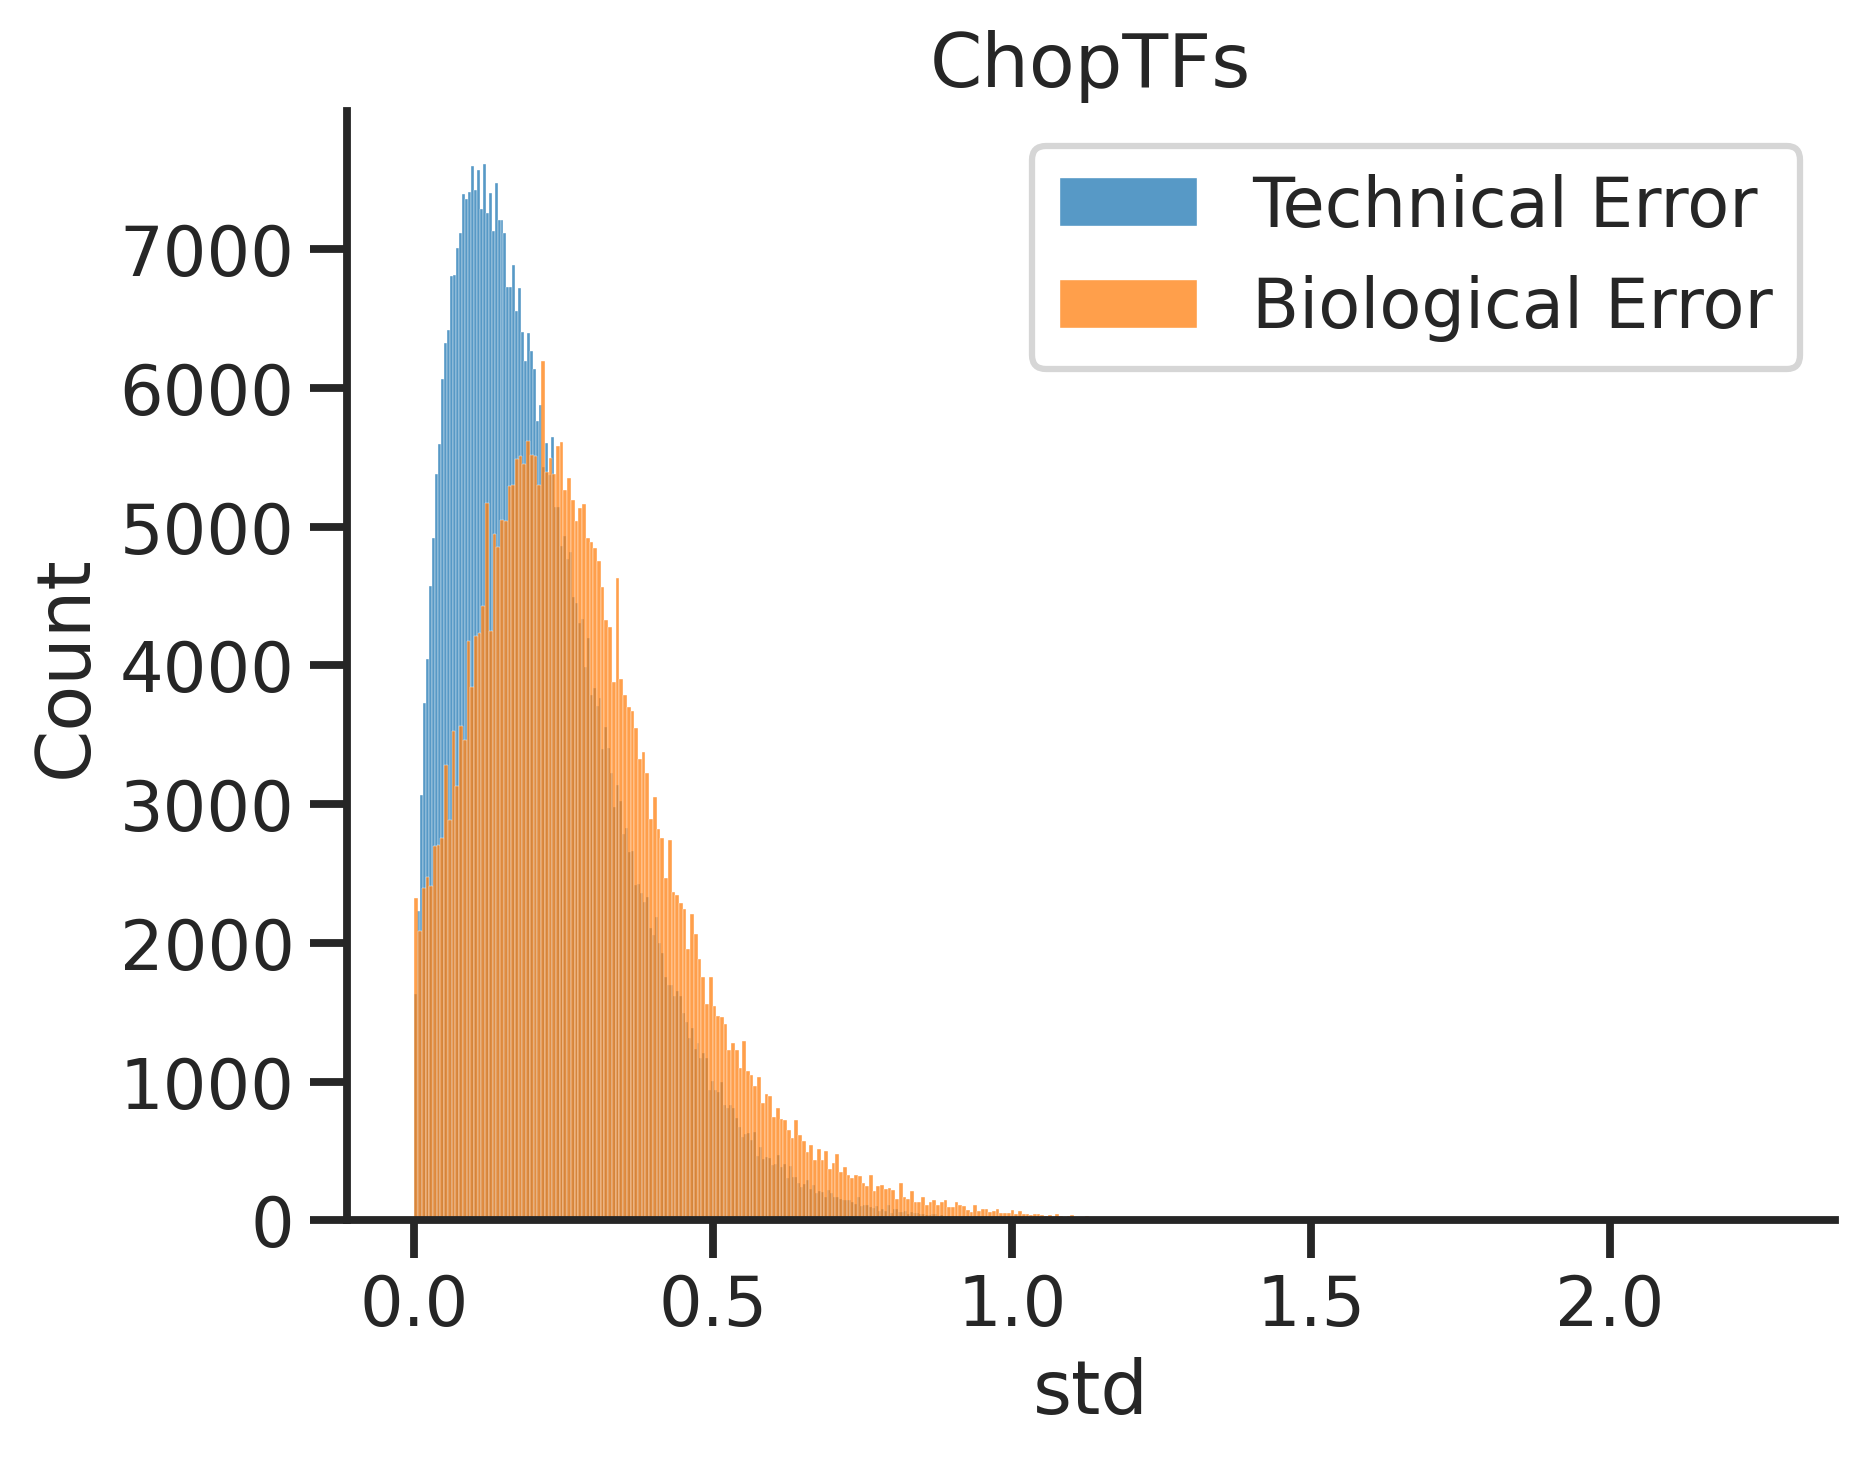

In [11]:
plt.figure(dpi = 300)
sns.histplot(tech_rep_err['std'], label = "Technical Error")
sns.histplot(bio_rep_err['std'], label = "Biological Error")
plt.legend()
plt.title("ChopTFs")
sns.despine()
plt.show()

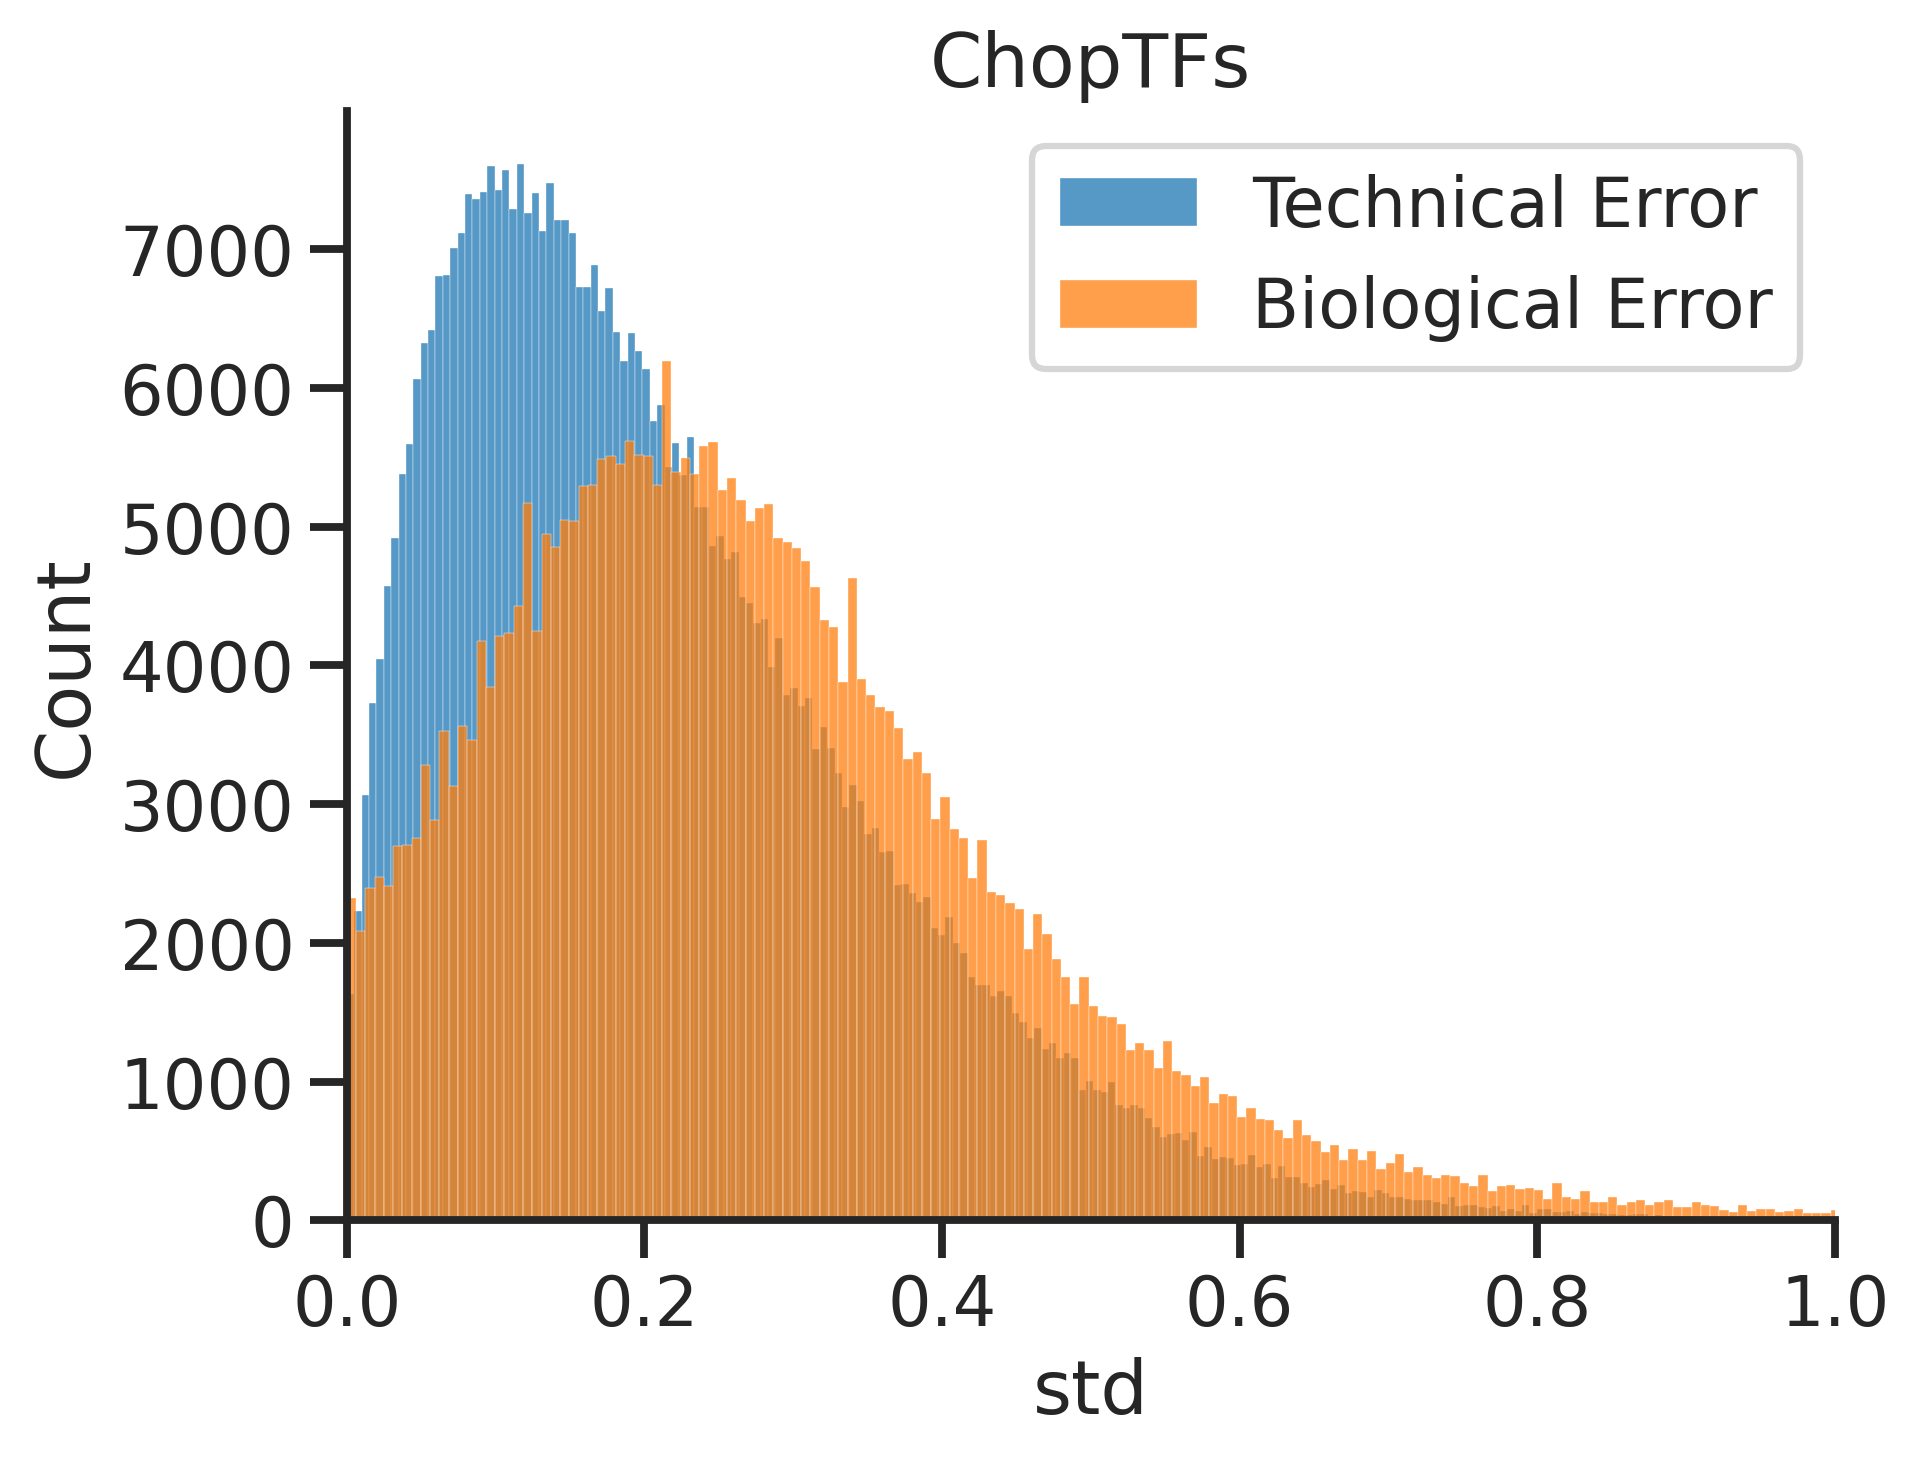

In [12]:
plt.figure(dpi = 300)
sns.histplot(tech_rep_err['std'], label = "Technical Error")
sns.histplot(bio_rep_err['std'], label = "Biological Error")
plt.legend()
plt.title("ChopTFs")
plt.xlim(0,1)
sns.despine()
plt.show()

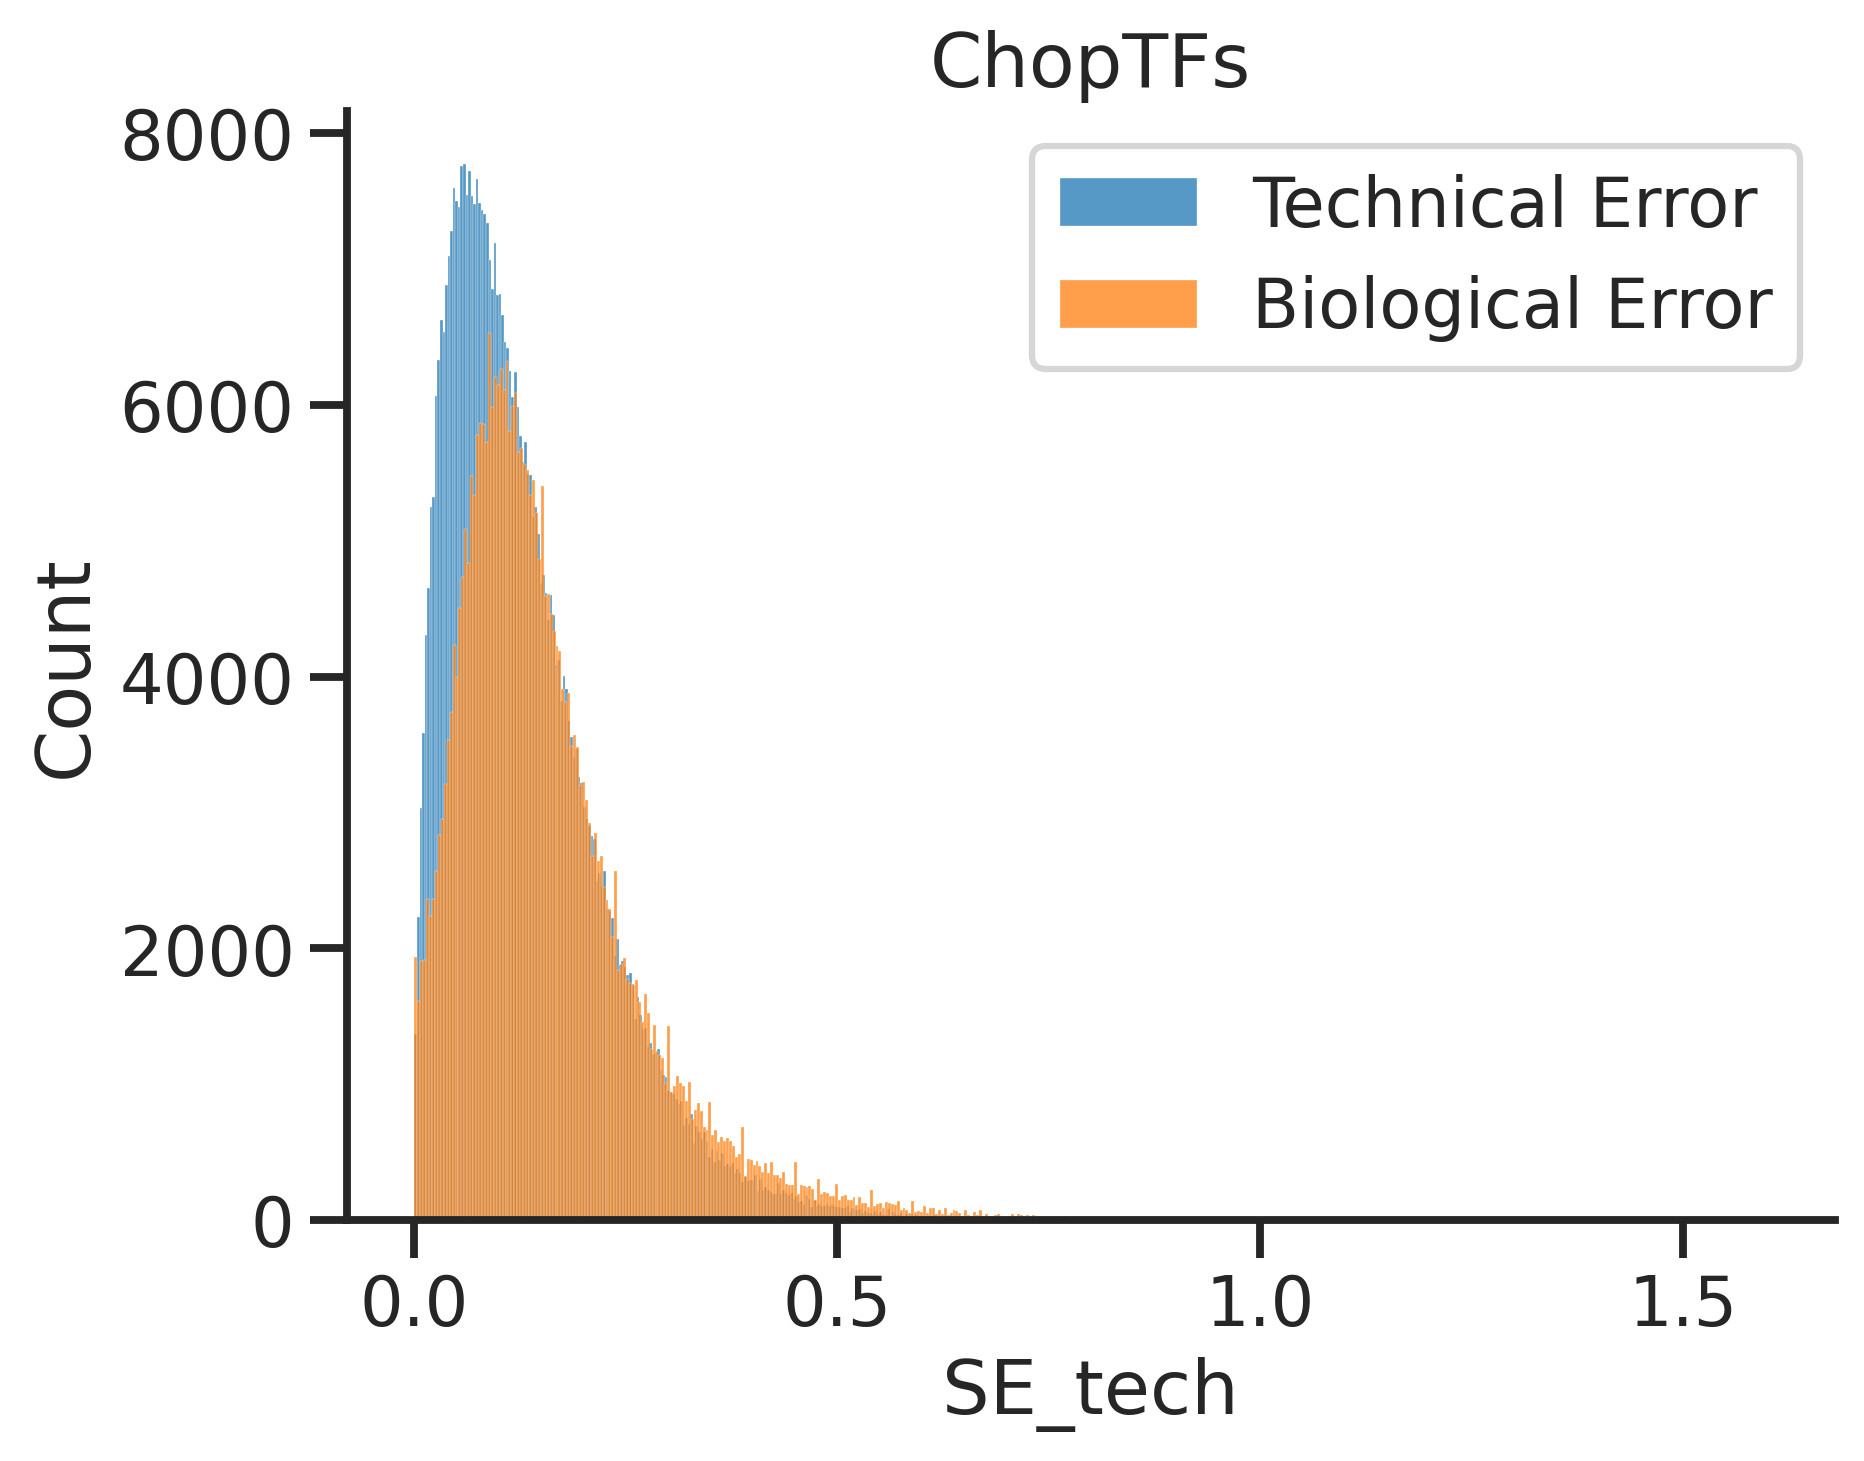

In [13]:
plt.figure(dpi = 300)
sns.histplot(tech_rep_err['SE_tech'], label = "Technical Error")
sns.histplot(bio_rep_err['SE_bio'], label = "Biological Error")
plt.legend()
plt.title("ChopTFs")
sns.despine()
plt.show()

# How mnay bio reps and tech reps do I have?

In [14]:
bio_rep_counts = pd.DataFrame(df[["ADseq", "AD_BC", "RPTR_BC", "rep", "time"]].groupby(["ADseq", "rep", "time"]).size()).reset_index()
bio_rep_counts

,ADseq,rep,time,0
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,2,15,1
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,3,30,1
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,2
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,3
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,3
...,...,...,...,...
472407,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,20,1
472408,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,30,1
472409,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,40,1
472410,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,4,50,1


In [15]:
bio_rep_counts[bio_rep_counts[0] > 3]

,ADseq,rep,time,0
32,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,2,0,5
33,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,2,2,5
34,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,2,5,5
35,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,2,10,6
36,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,2,15,6
...,...,...,...,...
472377,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,20,4
472378,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,30,4
472379,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,40,4
472380,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,50,4


<Axes: xlabel='0', ylabel='Count'>

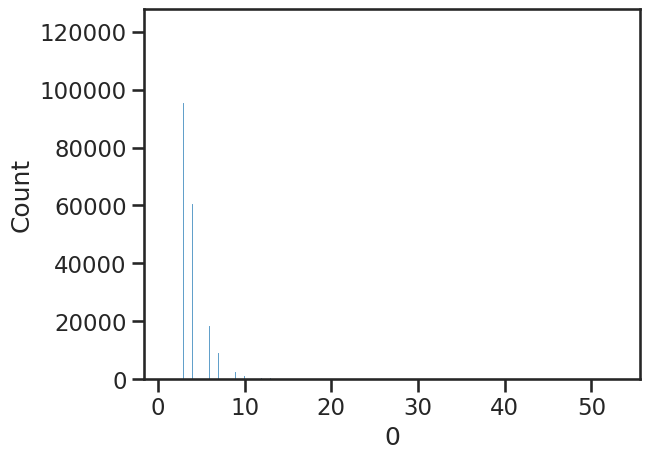

In [16]:
sns.histplot(bio_rep_counts[0])

In [17]:
tech_rep_counts = pd.DataFrame(df[["ADseq", "AD_BC", "RPTR_BC", "rep", "time"]].groupby(["ADseq", "AD_BC", "RPTR_BC", "time"]).size()).reset_index()
tech_rep_counts

,ADseq,AD_BC,RPTR_BC,time,0
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,ACGGTTATCTT,CCCCCAAGTACAAA,15,1
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,ACGGTTATCTT,CCCCCAAGTACAAA,30,1
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,0,1
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,2,1
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,AACCCATTAGA,CTATGCTCAAGTTA,5,2
...,...,...,...,...,...
538773,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,20,3
538774,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,30,3
538775,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,40,3
538776,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,GTATCCTCCCG,TGTACCTTAATCAT,50,3


<Axes: xlabel='0', ylabel='Count'>

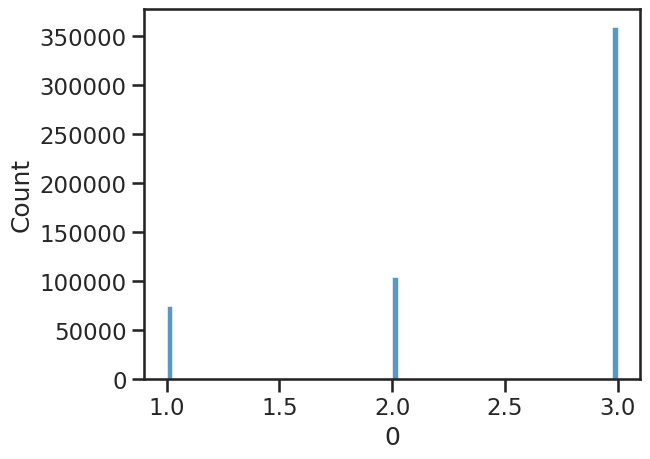

In [18]:
sns.histplot(tech_rep_counts[0])

# Collapsing tech reps and then collapsing across bio reps

In [19]:
dbd_norm_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities.csv")
dbd_norm_activities = dbd_norm_activities[["ADseq",  "AD_BC", "RPTR_BC", "time", "rep", "shifted_activity"]]
# dbd_norm_activities = dbd_norm_activities.groupby(["ADseq", "rep", "time"])[["shifted_activity"]].agg(["mean", "std"]).reset_index()
# dbd_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dbd_norm_activities.columns]
# dbd_norm_activities = dbd_norm_activities[dbd_norm_activities["rep_"] == 2]
# dbd_norm_activities = dbd_norm_activities.dropna()
df = dbd_norm_activities
df["bio_rep"] = df["AD_BC"] + "_" + df["RPTR_BC"]
df

,ADseq,AD_BC,RPTR_BC,time,rep,shifted_activity,bio_rep
0,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,ATAACCAATGG,TGAGAGAAAATCTA,0,2,-0.150595,ATAACCAATGG_TGAGAGAAAATCTA
1,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,TATCTTCGCTT,CCCTCACCCGATTA,0,2,-0.329160,TATCTTCGCTT_CCCTCACCCGATTA
2,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,AATCGTACCGA,TTTGATATCCAAAC,0,2,-0.396107,AATCGTACCGA_TTTGATATCCAAAC
3,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTGCATAGCTG,TATTGTTCTCTGCT,0,2,-0.748290,TTGCATAGCTG_TATTGTTCTCTGCT
4,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,TTTATAATACC,CATCGAACCTGAAC,0,2,-0.073888,TTTATAATACC_CATCGAACCTGAAC
...,...,...,...,...,...,...,...
1361924,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCAAACTTGGA,CAATTGACACTACG,60,4,-0.375924,CCAAACTTGGA_CAATTGACACTACG
1361925,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,CCCACTCTCAG,CGCACGAATACCCG,60,4,-0.207950,CCCACTCTCAG_CGCACGAATACCCG
1361926,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,GGGTCGTAAAT,CAACAGCCCTTACG,60,4,0.320323,GGGTCGTAAAT_CAACAGCCCTTACG
1361927,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,GATCCCATGCA,CTCTGCTACTTGTG,60,4,0.324968,GATCCCATGCA_CTCTGCTACTTGTG


In [20]:
bio = (
    df.groupby(["ADseq", "time", "bio_rep"])
    .agg(
        mean_activity=("shifted_activity", "mean")
    )
    .reset_index()
)
bio

,ADseq,time,bio_rep,mean_activity
0,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,15,ACGGTTATCTT_CCCCCAAGTACAAA,1.460117
1,AAAAAAASNSYAIPENELLDEDTMNFISSLKNDLSNISNS,30,ACGGTTATCTT_CCCCCAAGTACAAA,0.755067
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,0,AACCCATTAGA_CTATGCTCAAGTTA,0.214090
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,0,AAGGAACTAGC_CGAGCTTCACATAG,0.096808
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,0,AATCTGAATAT_GGTGGCGTAATTGT,0.249748
...,...,...,...,...
538773,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,30,ATCCATATAGT_ACCTTTGATCCTCA,0.863685
538774,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,30,GTATCCTCCCG_TGTACCTTAATCAT,-0.361356
538775,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,40,GTATCCTCCCG_TGTACCTTAATCAT,-0.270341
538776,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,50,GTATCCTCCCG_TGTACCTTAATCAT,-0.226925


In [21]:
bio.to_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_tech_reps_collapsed.csv")

In [22]:
summary = (
    bio.groupby(["ADseq", "time"])
    .agg(
        mean_activity=("mean_activity", "mean"),
        sd=("mean_activity", "std"),
        n_bio=("mean_activity", "count")
    )
    .reset_index()
)
summary = summary.dropna()
summary

,ADseq,time,mean_activity,sd,n_bio
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,0,0.186882,0.080018,3
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.340462,0.047206,3
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.467590,0.333105,3
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.239009,0.212394,3
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.190206,0.112335,3
...,...,...,...,...,...
164679,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,60,0.736019,0.274903,4
164682,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,5,-0.084863,0.715209,2
164683,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,10,-0.011900,0.293554,2
164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,20,0.307908,0.710601,2


100%|██████████| 10/10 [00:00<00:00, 42.94it/s]


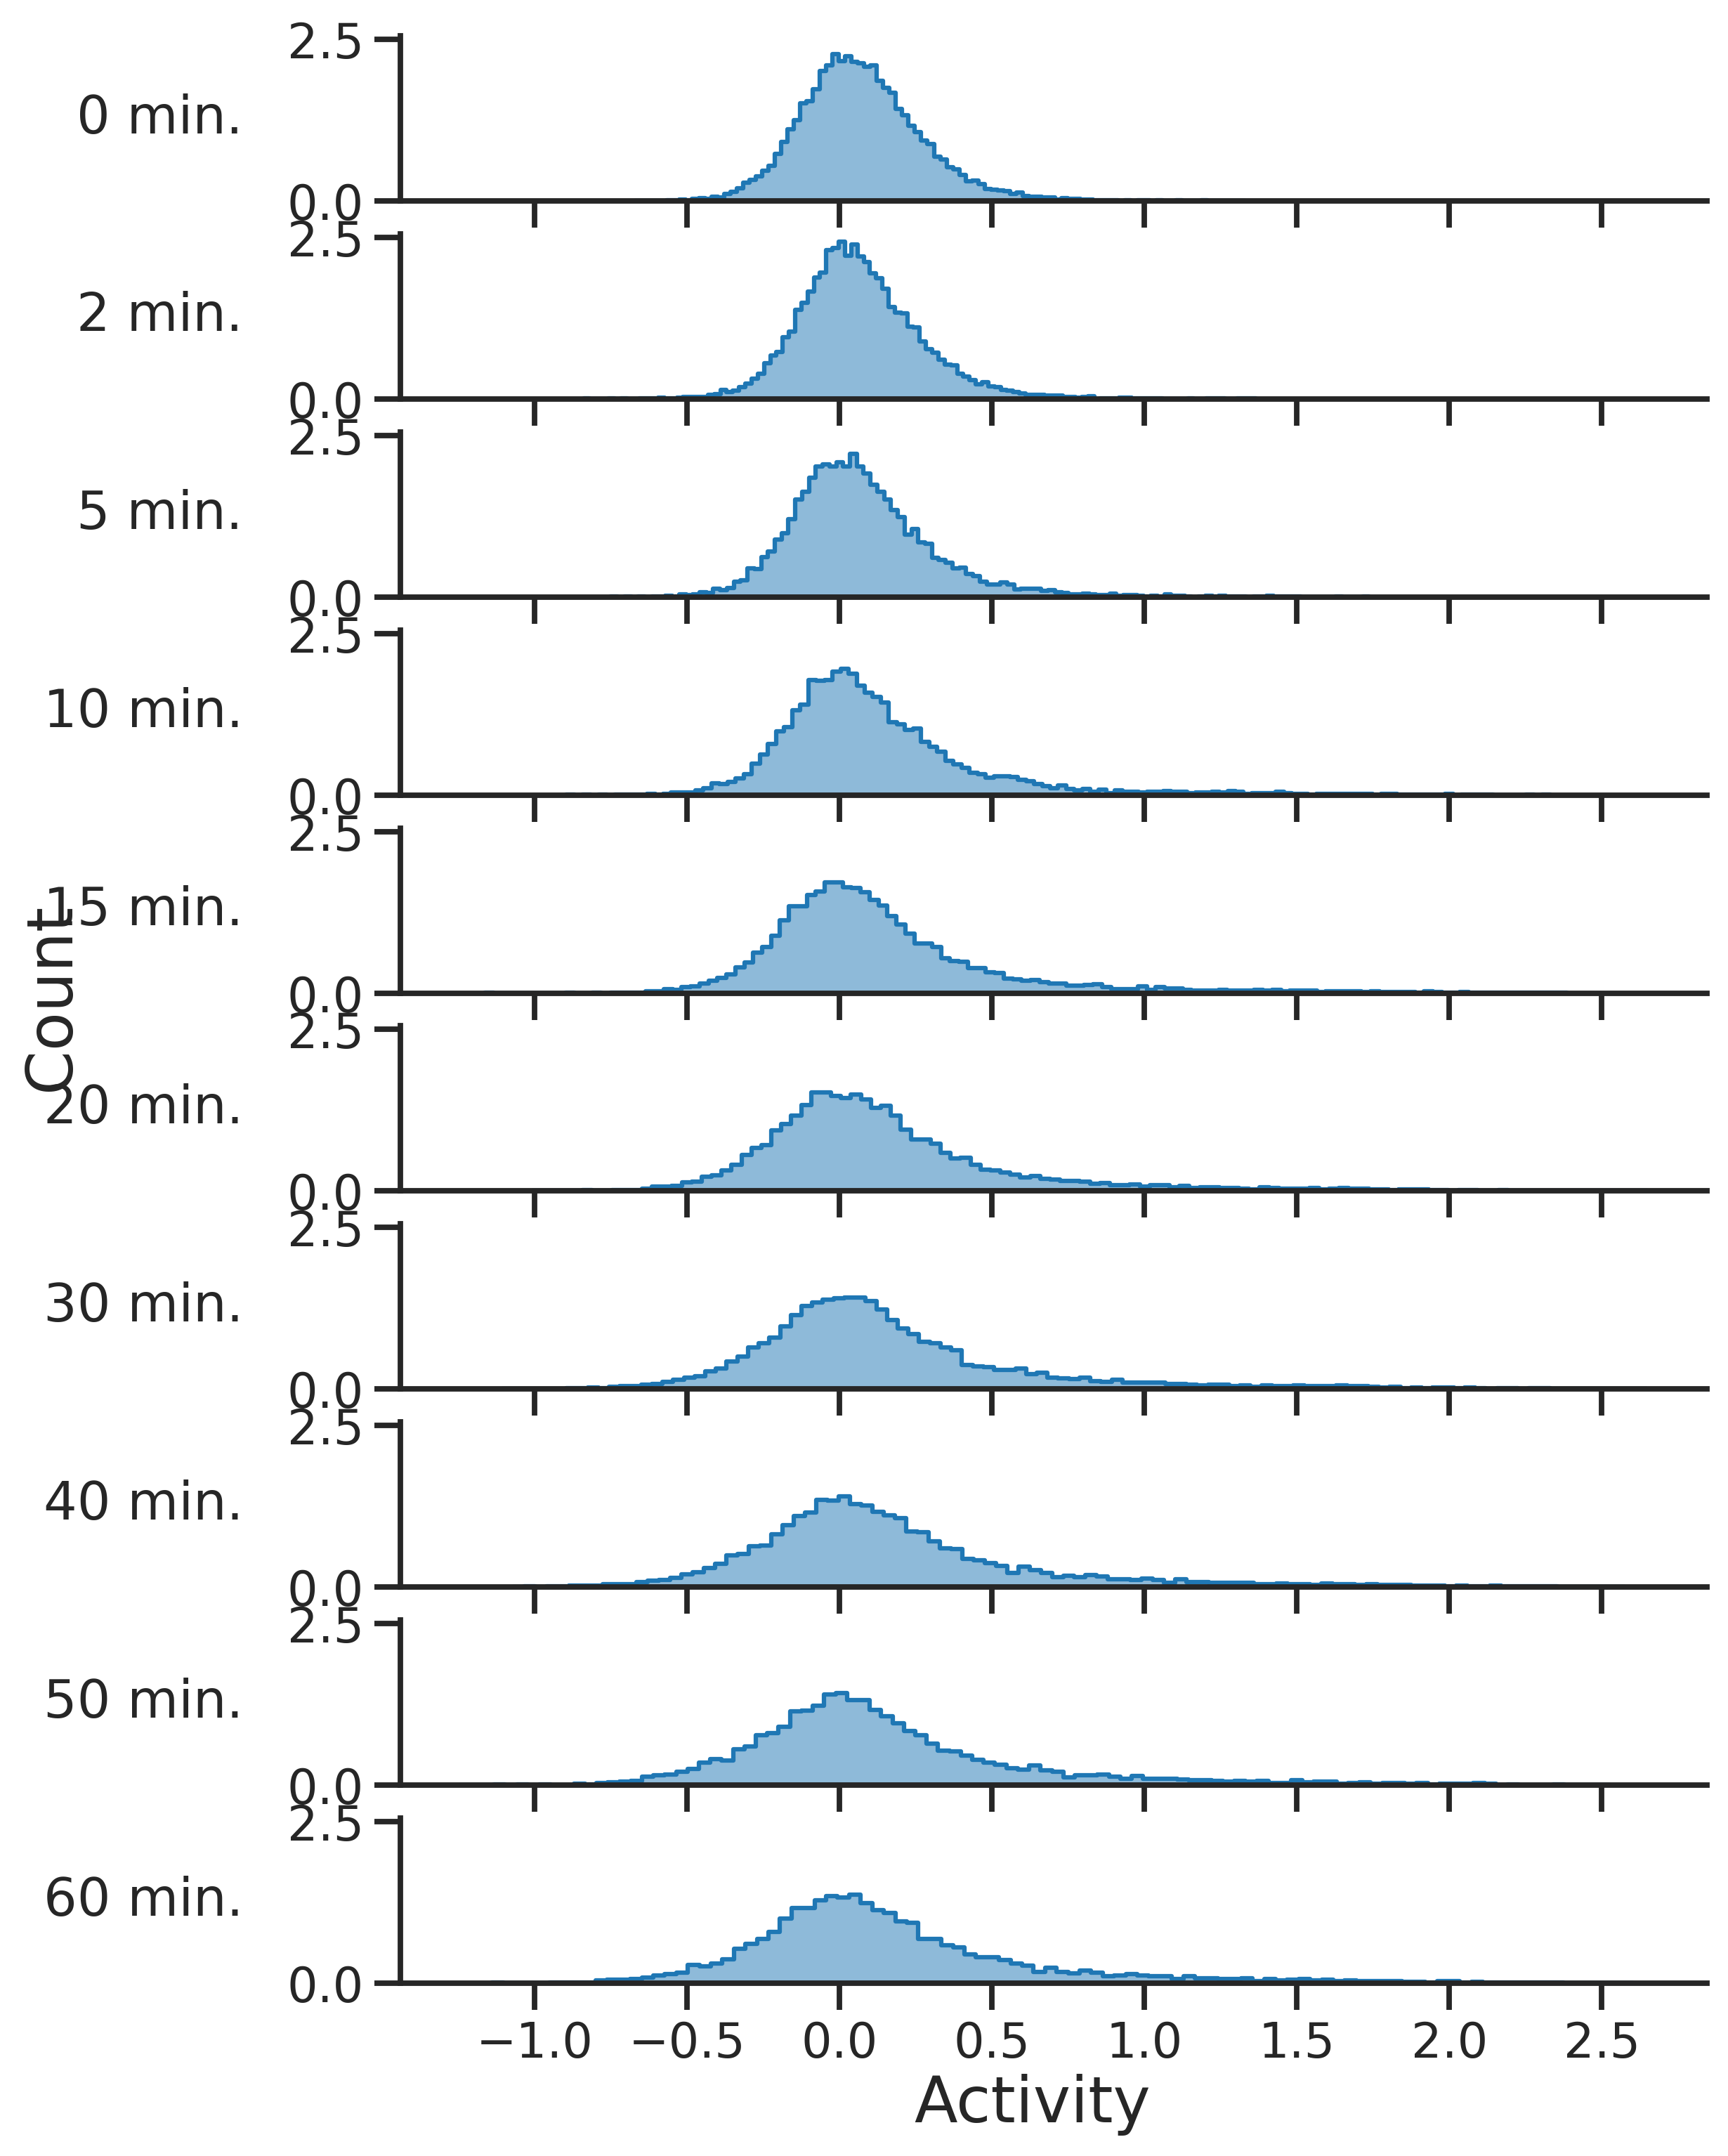

In [23]:
fig, axs = time_normalization_helpers.plot_hists_over_time(summary, column = "mean_activity")
# for ax in axs:
#     sns.despine(ax = ax, left = True, bottom = True)

/tmp/ipykernel_2247095/400881768.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1], pad = 0.5)


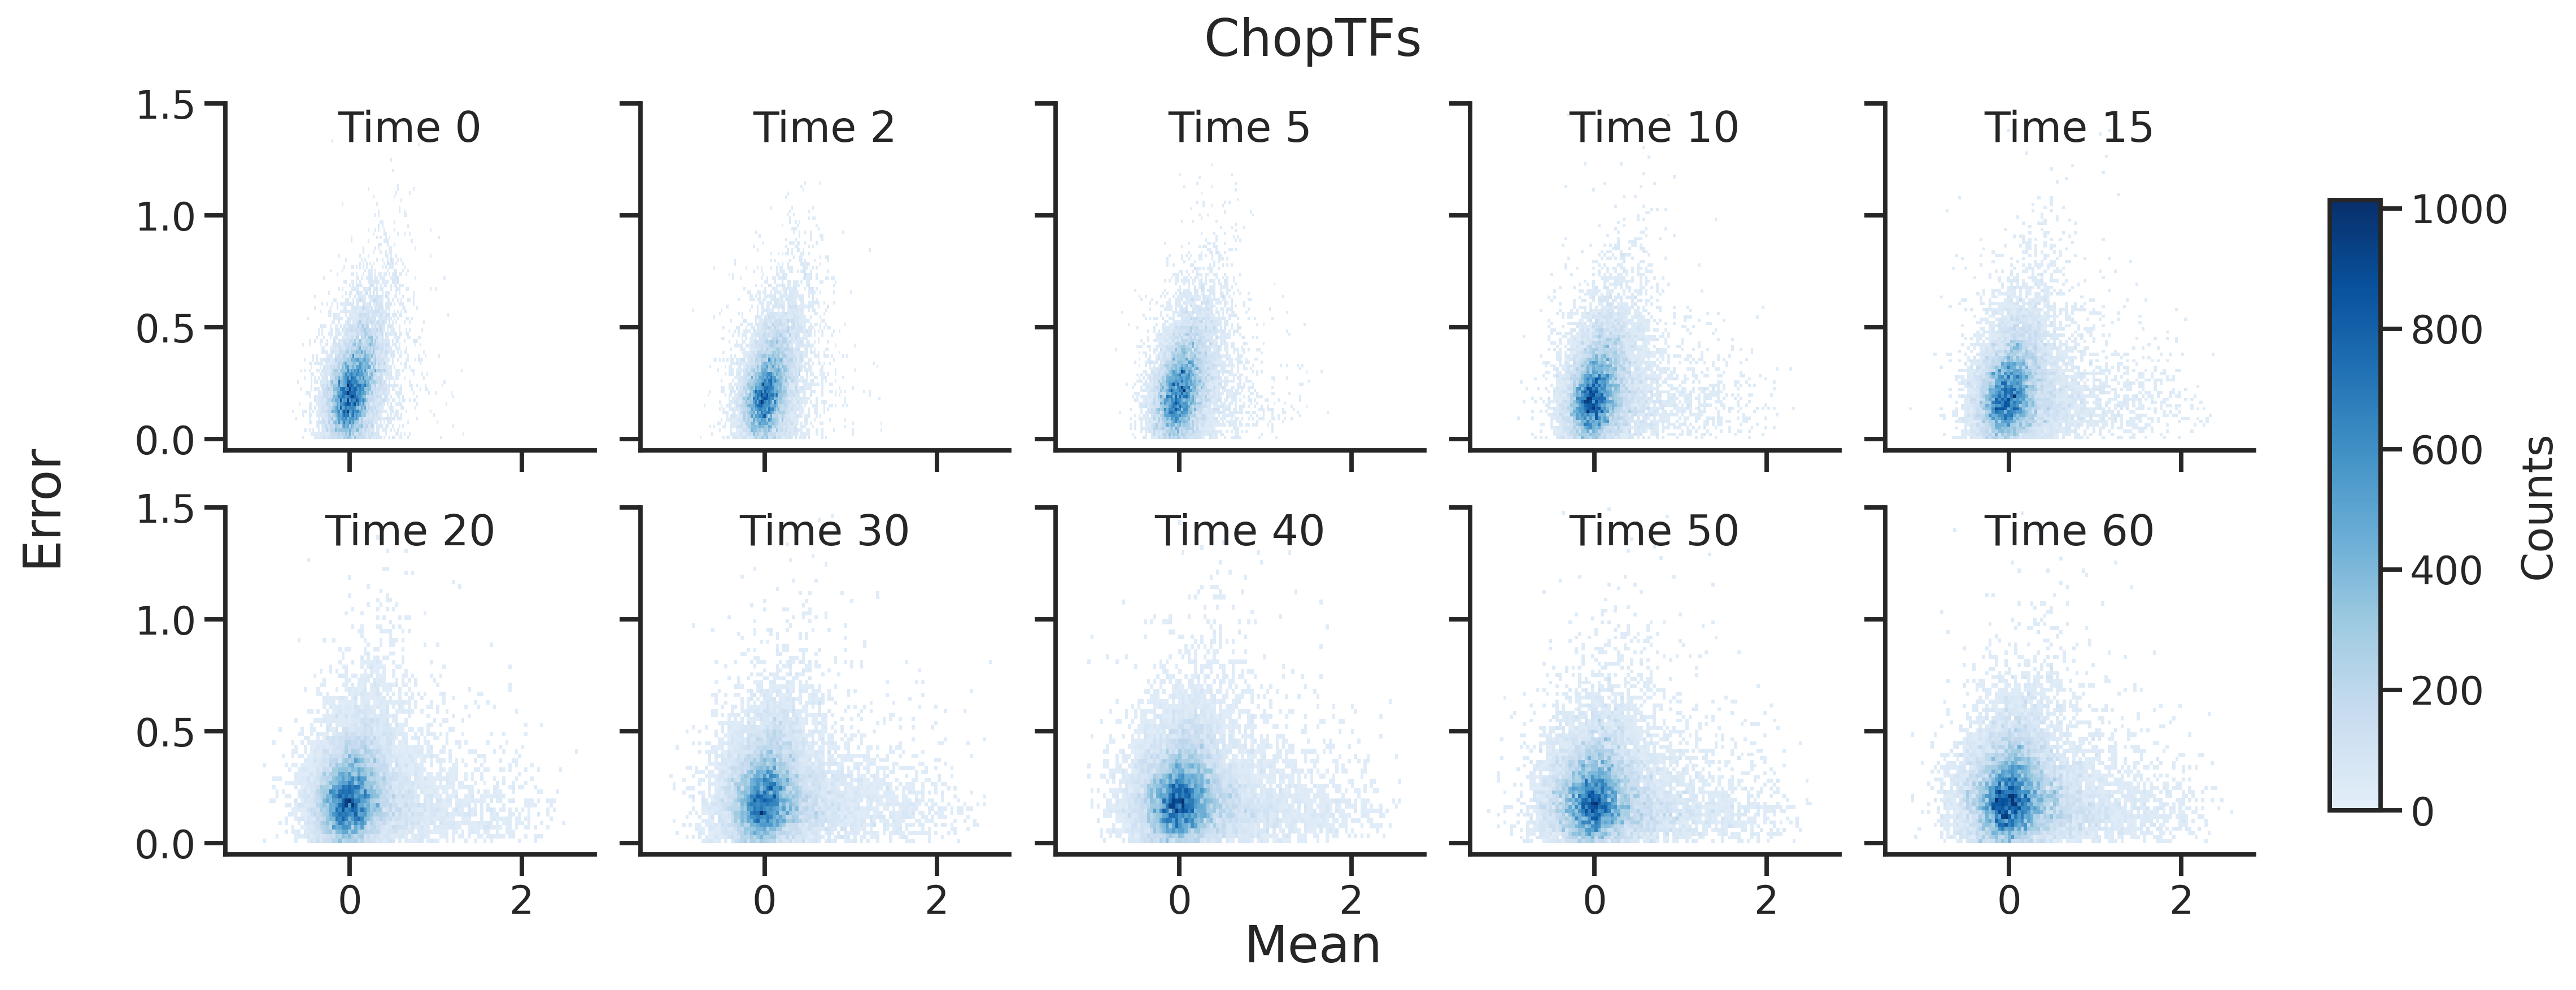

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

sns.set_context("talk")
sns.set_style('ticks')

df = summary.copy()

# --- Truncate colormap (same as yours) ---
def truncate_colormap(cmap, minval=0.15, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mpl.colors.LinearSegmentedColormap.from_list("trunc", new_colors)

cmap = truncate_colormap(mpl.cm.Blues, 0.1, 1.0)

# --- Global max for consistent color scaling ---
# Drop NaNs and infs for histogram calculation
clean = df[["mean_activity", "sd"]].replace([np.inf, -np.inf], np.nan).dropna()

counts, _, _ = np.histogram2d(clean["mean_activity"], clean["sd"], bins=80)
global_max = counts.max()
global_max = counts.max()

# --- Sort times ---
times = sorted(df["time"].unique())

# --- Layout ---
n = len(times)
cols = min(5, n)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows),
                         sharex=True, sharey=True, dpi=300)

axes = np.array(axes).reshape(-1)

# --- Global axis limits ---
xmin, xmax = df["mean_activity"].min(), df["mean_activity"].max()
ymin, ymax = df["sd"].min(), df["sd"].max()

xpad, ypad = 1, 1
ymin, ymax = ymin - ypad, ymax + ypad

# --- Plot ---
for i, time in enumerate(times):
    ax = axes[i]
    subset = df[df["time"] == time]

    sns.histplot(
        data=subset,
        x="mean_activity",
        y="sd",
        bins=100,
        cmap=cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(f"Time {time}", y=0.85)
    # ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.05,1.5)
    ax.set_xlabel("")
    ax.set_ylabel("")

# --- Turn off unused axes ---
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# --- Shared labels ---
fig.supxlabel("Mean", y=0.04)
fig.supylabel("Error", x = -0.01)

# --- Shared colorbar ---
sm = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=0, vmax=global_max),
    cmap=cmap
)
sm.set_array([])

cbar_ax = fig.add_axes([0.9, 0.2, 0.02, 0.6])
fig.colorbar(sm, cax=cbar_ax, label="Counts")
fig.suptitle("ChopTFs")

# --- Layout polish ---
plt.tight_layout(rect=[0, 0, 0.88, 1], pad = 0.5)
sns.despine()
plt.show()

In [25]:
summary_to_save = summary.rename(columns = {"mean_activity" : "activity"})
summary_to_save

,ADseq,time,activity,sd,n_bio
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,0,0.186882,0.080018,3
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.340462,0.047206,3
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.467590,0.333105,3
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.239009,0.212394,3
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.190206,0.112335,3
...,...,...,...,...,...
164679,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,60,0.736019,0.274903,4
164682,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,5,-0.084863,0.715209,2
164683,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,10,-0.011900,0.293554,2
164685,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,20,0.307908,0.710601,2


In [26]:
summary_to_save.to_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_bio_error.csv")